# Import

In [77]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use("ggplot")

# 한글 폰트 설정하기
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

# DataLoad

In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
path = '/content/drive/MyDrive/Colab_Notebooks/kpi/data'
customer = pd.read_csv(path + '/customers.csv')
location = pd.read_csv(path + '/locations.csv')
order_items = pd.read_csv(path + '/order_items.csv')
orders = pd.read_csv(path + '/orders.csv')
payments = pd.read_csv(path + '/payments.csv')
product = pd.read_csv(path + '/products.csv')
review = pd.read_csv(path + '/reviews.csv')
seller = pd.read_csv(path + '/sellers.csv')

# 데이터 전처리

## Order_id와 Product_id기준으로 merge

In [81]:

order_merge = pd.merge(order_items, orders, on='Order_id', how='inner')
order_merge = pd.merge(order_merge, payments, on='Order_id', how='inner')
order_merge = pd.merge(order_merge, review, on='Order_id', how='inner')
order_merge = pd.merge(order_merge, product, on='Product_id', how='inner')
customer_temp = customer[['Customer_id','Customer_city']]
order_merge = pd.merge(order_merge, customer_temp, on='Customer_id', how='inner')
order_merge.head()


,Order_id,Order_item_id,Product_id,Seller_id,Price,Freight_value,Customer_id,Order_status,Order_purchase_timestamp,Order_delivered_carrier_date,...,Review_id,Review_score,Review_creation_date,Review_answer_timestamp,Product_category_name,Product_weight_g,Product_length_cm,Product_height_cm,Product_width_cm,Customer_city
0,ORDER_75477,1,PRODUCT_23128,SELLER_0452,58.9,13.29,CUSTOMER_58023,delivered,2018-09-13 08:59:02,2018-09-19 18:34:16,...,REVIEW_45875,5,2018-09-21 00:00:00,2018-09-22 10:57:03,cool_stuff,650.0,28.0,9.0,14.0,campos dos goytacazes
1,ORDER_56792,1,PRODUCT_23128,SELLER_0452,55.9,17.96,CUSTOMER_71706,delivered,2018-06-28 11:52:20,2018-07-05 12:00:33,...,REVIEW_13066,5,2018-07-14 00:00:00,2018-07-17 12:50:07,cool_stuff,650.0,28.0,9.0,14.0,jatai
2,ORDER_09038,1,PRODUCT_23128,SELLER_0452,64.9,18.33,CUSTOMER_22610,delivered,2019-05-18 10:25:53,2019-05-23 14:05:00,...,REVIEW_04286,4,2019-06-05 00:00:00,2019-06-06 21:41:12,cool_stuff,650.0,28.0,9.0,14.0,belo horizonte
3,ORDER_52334,1,PRODUCT_23128,SELLER_0452,58.9,16.17,CUSTOMER_20322,delivered,2018-08-01 18:38:42,2018-08-02 19:07:36,...,REVIEW_69124,5,2018-08-10 00:00:00,2018-08-13 03:35:17,cool_stuff,650.0,28.0,9.0,14.0,sao jose dos pinhais
4,ORDER_36691,1,PRODUCT_23128,SELLER_0452,58.9,13.29,CUSTOMER_02269,delivered,2018-08-10 21:48:40,2018-08-11 19:43:07,...,REVIEW_16030,5,2018-08-25 00:00:00,2018-08-28 00:51:18,cool_stuff,650.0,28.0,9.0,14.0,conselheiro lafaiete


## delivery_delay, delivery_day 변수 추가 생성

In [82]:
#delivery_delay : 실제 배송 시간 - 예상 배송 날짜
order_merge['delivery_delay'] = (pd.to_datetime(order_merge['Order_delivered_customer_date']) - pd.to_datetime(order_merge['Order_estimated_delivery_date'])).dt.days
#delivery_day : 실제 배송 시간 - 주문 시간
order_merge['delivery_day'] = (pd.to_datetime(order_merge['Order_delivered_customer_date']) - pd.to_datetime(order_merge['Order_purchase_timestamp'])).dt.days
order_merge.head()


,Order_id,Order_item_id,Product_id,Seller_id,Price,Freight_value,Customer_id,Order_status,Order_purchase_timestamp,Order_delivered_carrier_date,...,Review_creation_date,Review_answer_timestamp,Product_category_name,Product_weight_g,Product_length_cm,Product_height_cm,Product_width_cm,Customer_city,delivery_delay,delivery_day
0,ORDER_75477,1,PRODUCT_23128,SELLER_0452,58.9,13.29,CUSTOMER_58023,delivered,2018-09-13 08:59:02,2018-09-19 18:34:16,...,2018-09-21 00:00:00,2018-09-22 10:57:03,cool_stuff,650.0,28.0,9.0,14.0,campos dos goytacazes,-9,7
1,ORDER_56792,1,PRODUCT_23128,SELLER_0452,55.9,17.96,CUSTOMER_71706,delivered,2018-06-28 11:52:20,2018-07-05 12:00:33,...,2018-07-14 00:00:00,2018-07-17 12:50:07,cool_stuff,650.0,28.0,9.0,14.0,jatai,-13,15
2,ORDER_09038,1,PRODUCT_23128,SELLER_0452,64.9,18.33,CUSTOMER_22610,delivered,2019-05-18 10:25:53,2019-05-23 14:05:00,...,2019-06-05 00:00:00,2019-06-06 21:41:12,cool_stuff,650.0,28.0,9.0,14.0,belo horizonte,-3,17
3,ORDER_52334,1,PRODUCT_23128,SELLER_0452,58.9,16.17,CUSTOMER_20322,delivered,2018-08-01 18:38:42,2018-08-02 19:07:36,...,2018-08-10 00:00:00,2018-08-13 03:35:17,cool_stuff,650.0,28.0,9.0,14.0,sao jose dos pinhais,-16,8
4,ORDER_36691,1,PRODUCT_23128,SELLER_0452,58.9,13.29,CUSTOMER_02269,delivered,2018-08-10 21:48:40,2018-08-11 19:43:07,...,2018-08-25 00:00:00,2018-08-28 00:51:18,cool_stuff,650.0,28.0,9.0,14.0,conselheiro lafaiete,-8,13


# 시각화

## 리뷰 점수별 delivery_delay의 분포 시각화

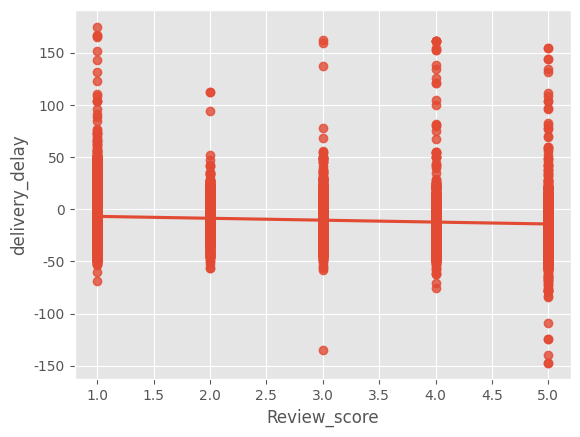

In [83]:
import matplotlib.pyplot as plt
sns.regplot(x='Review_score', y='delivery_delay', data=order_merge)
plt.show()


## 리뷰 점수별 delivery_day의 분포 시각화

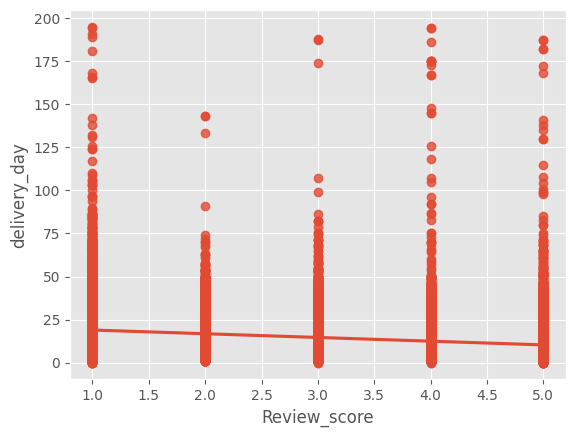

In [84]:
# Review_score 와 delivery_day간의 상관관계
sns.regplot(x='Review_score', y='delivery_day', data=order_merge)
plt.show()

##order_item_id의 개수 시각화

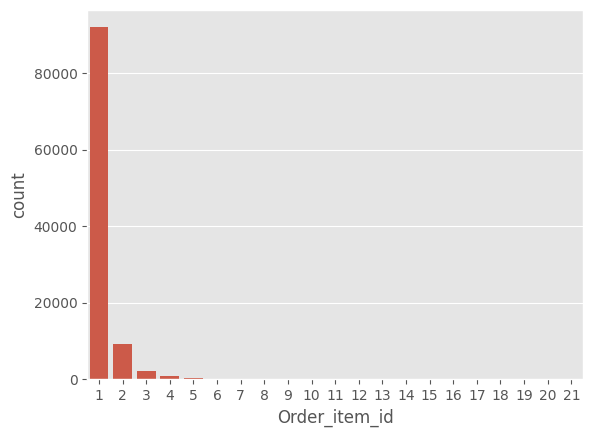

In [85]:
sns.countplot(x='Order_item_id', data=order_merge)
plt.show()


## 월별 전체 주문수중 1점을 준 비율을 %로 시각화

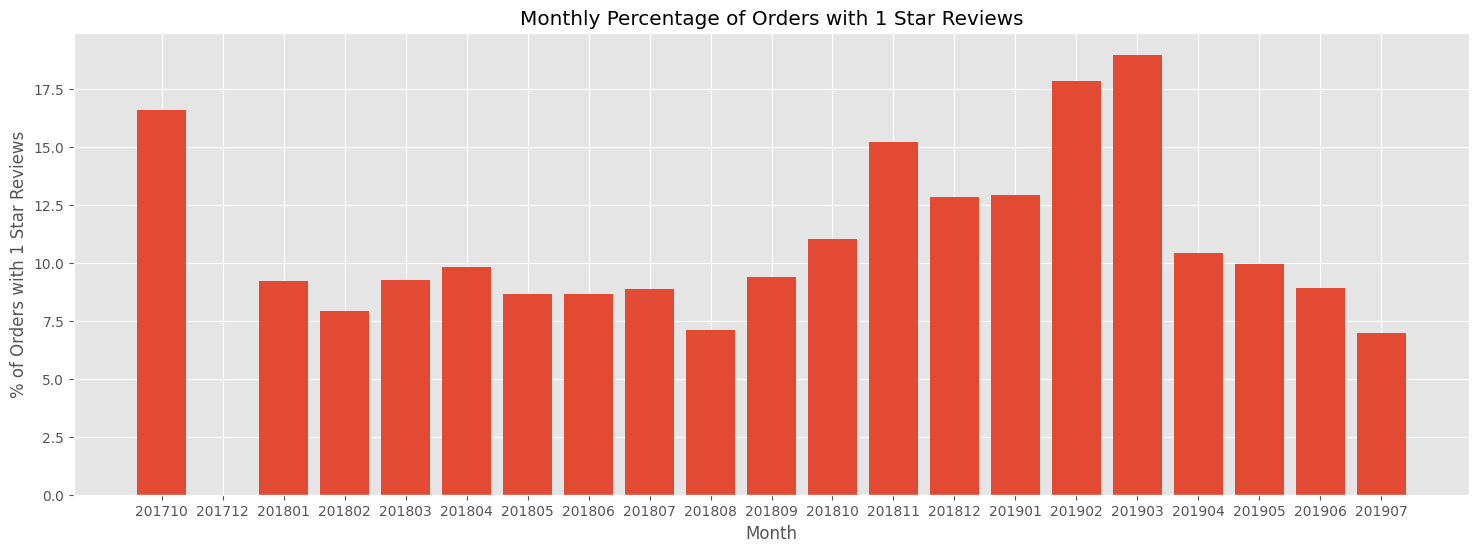

In [86]:
# 월별로 고객수 시각화

# 주문 월별로 그룹화
order_monthly = order_merge.groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.month)['Customer_id'].nunique()

# 고객 유지율 계산
retention_rate = order_monthly / order_monthly.shift(1)

#월별 전체 주문수중에 1점을 준 비율을 퍼센트로 보여주고 seaborn의 barplot으로 시각화

# 월별로 주문수와 1점 리뷰수 계산
monthly_orders = order_merge.groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.strftime('%Y%m'))['Order_id'].count()
monthly_bad_reviews = order_merge[order_merge['Review_score'] == 1].groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.strftime('%Y%m'))['Order_id'].count()

# 월별 1점 리뷰 비율 계산
monthly_bad_review_rate = (monthly_bad_reviews / monthly_orders) * 100

# 시각화
plt.figure(figsize=(18, 6))
plt.bar(monthly_bad_review_rate.index, monthly_bad_review_rate.values)
plt.xlabel('Month')
plt.ylabel('% of Orders with 1 Star Reviews')
plt.title('Monthly Percentage of Orders with 1 Star Reviews')
plt.show()

## 월별 전체 주문수중에 1~2점을 준 비율을 %로 보여주고 시각화

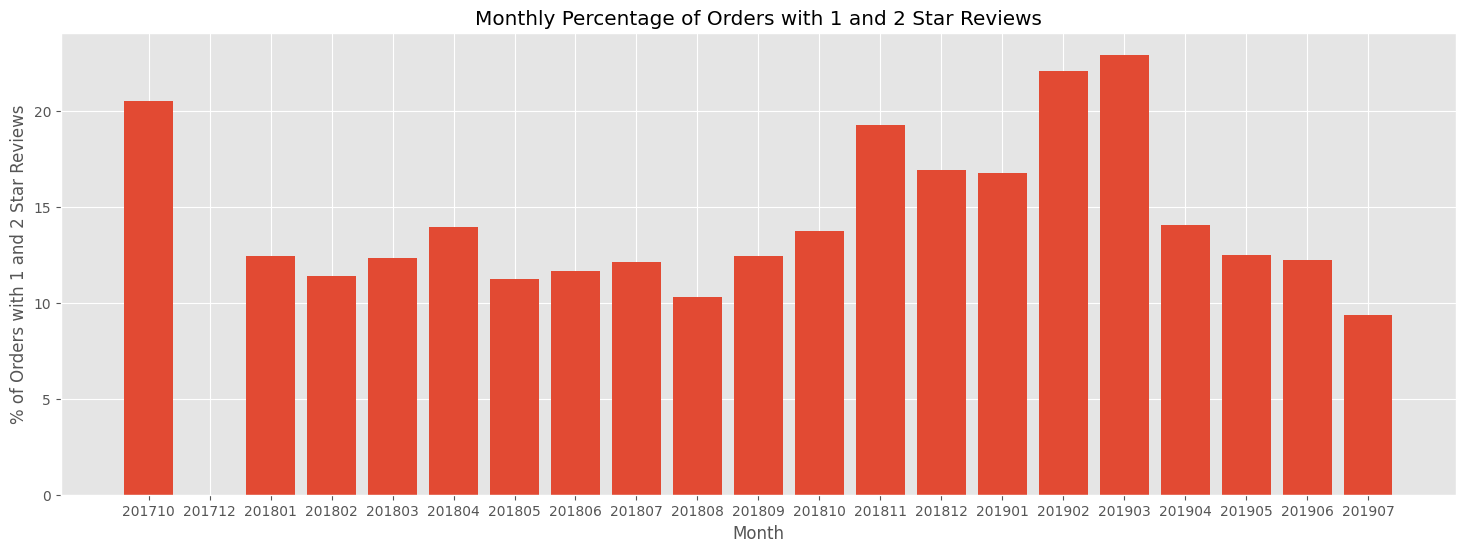

In [87]:
# 월별로 주문수와 1~2점 리뷰수 계산
monthly_orders = order_merge.groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.strftime('%Y%m'))['Order_id'].count()
monthly_bad_reviews = order_merge[order_merge['Review_score'] <= 2].groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.strftime('%Y%m'))['Order_id'].count()

# 월별 1~2점 리뷰 비율 계산
monthly_bad_review_rate = (monthly_bad_reviews / monthly_orders) * 100

# 시각화
plt.figure(figsize=(18, 6))
plt.bar(monthly_bad_review_rate.index, monthly_bad_review_rate.values)
plt.xlabel('Month')
plt.ylabel('% of Orders with 1 and 2 Star Reviews')
plt.title('Monthly Percentage of Orders with 1 and 2 Star Reviews')
plt.show()

## 제품별 전체 주문수중에 1~2점을 준 비율을 %로 보여주고 시각화

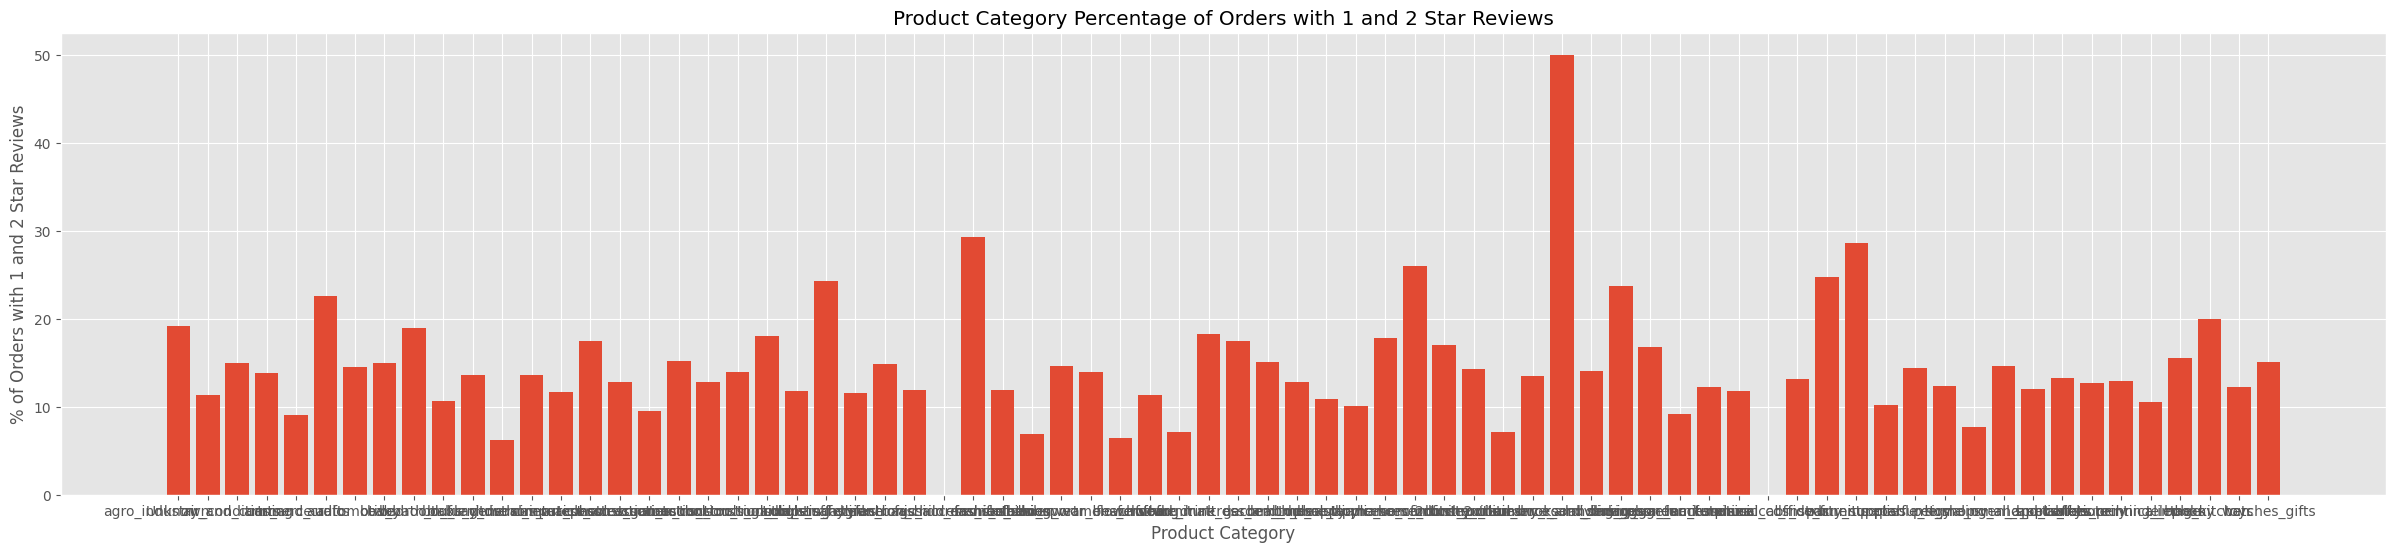

In [88]:
# 제품별 주문수와 1~2점 리뷰수 계산
product_orders = order_merge.groupby('Product_category_name')['Order_id'].count()
product_bad_reviews = order_merge[order_merge['Review_score'] <= 2].groupby('Product_category_name')['Order_id'].count()

# 제품별 1~2점 리뷰 비율 계산
product_bad_review_rate = (product_bad_reviews / product_orders) * 100

# 시각화
plt.figure(figsize=(30, 6))
plt.bar(product_bad_review_rate.index, product_bad_review_rate.values)
plt.xlabel('Product Category')
plt.ylabel('% of Orders with 1 and 2 Star Reviews')
plt.title('Product Category Percentage of Orders with 1 and 2 Star Reviews')
plt.show()


## 제품별 1~2점 리뷰 비율이 높은 상위 10개만 시각화

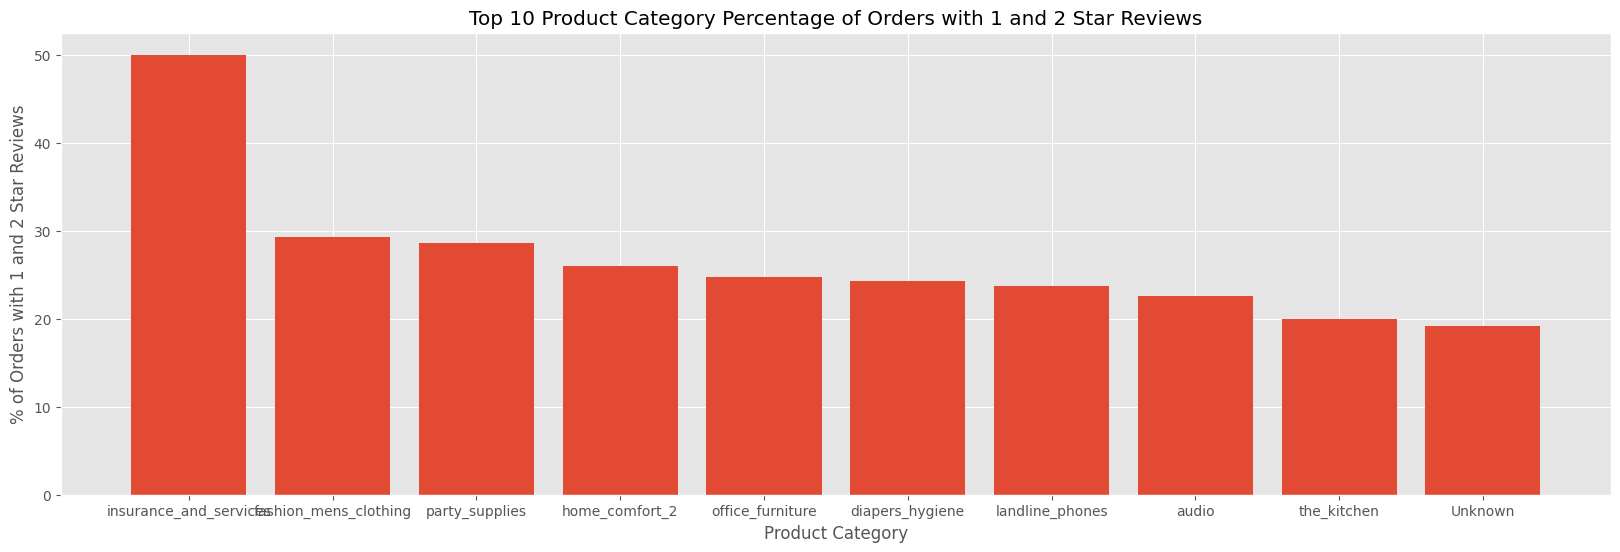

In [89]:
# 제품별 1~2점 리뷰 비율이 높은 상위 10개만 시각화

# 상위 10개만 추출
top_10_bad_review_rate = product_bad_review_rate.sort_values(ascending=False).head(10)

# 시각화
plt.figure(figsize=(20, 6))
plt.bar(top_10_bad_review_rate.index, top_10_bad_review_rate.values)
plt.xlabel('Product Category')
plt.ylabel('% of Orders with 1 and 2 Star Reviews')
plt.title('Top 10 Product Category Percentage of Orders with 1 and 2 Star Reviews')
plt.show()


# 검정

## Product_category_name과 Review_score와의 카이제곱 검정

In [90]:
# Product_category_name과 Review_score와의 카이제곱 검정
import scipy.stats as stats

crosstab = pd.crosstab(order_merge['Product_category_name'], order_merge['Review_score'])
chi2, p, dof, expected = stats.chi2_contingency(crosstab)

# 결과 출력
print('카이제곱 통계량:', chi2)
print('p-값:', p)
print('자유도:', dof)
print(crosstab)

카이제곱 통계량: 1578.7251453595213
p-값: 3.214886730451228e-178
자유도: 284
Review_score                  1    2    3     4     5
Product_category_name                                
Unknown                     249   56  110   323   854
agro_industry_and_commerce   20    5   13    41   141
air_conditioning             32    7   21    50   151
arts                         18    7   17    34   105
arts_and_crafts               1    0    3     3     4
...                         ...  ...  ...   ...   ...
technical_books              17    7    8    33   164
telephony                   491  160  438   899  2208
the_kitchen                   3    0    0     1    11
toys                        381  101  301   694  2465
watches_gifts               630  189  477  1032  3109

[72 rows x 5 columns]


## 상위 10개의 Product_category_name과 Review_score와의 카이제곱 검정

카이제곱 통계량: 498.2110611363519
p-값: 1.0785829220276305e-82
자유도: 36
Review_score              1    2     3     4     5
Product_category_name                             
bed_bath_table         1548  499  1067  2038  5657
health_beauty           890  214   688  1550  5291
sports_leisure          858  210   606  1577  4845
furniture_decor        1093  352   717  1447  4310
computers_accessories  1020  259   630  1474  3963
home_utilities          667  233   565  1187  3657
watches_gifts           630  189   477  1032  3109
garden_tools            503  135   340   828  2442
telephony               491  160   438   899  2208
toys                    381  101   301   694  2465


<Figure size 1000x600 with 0 Axes>

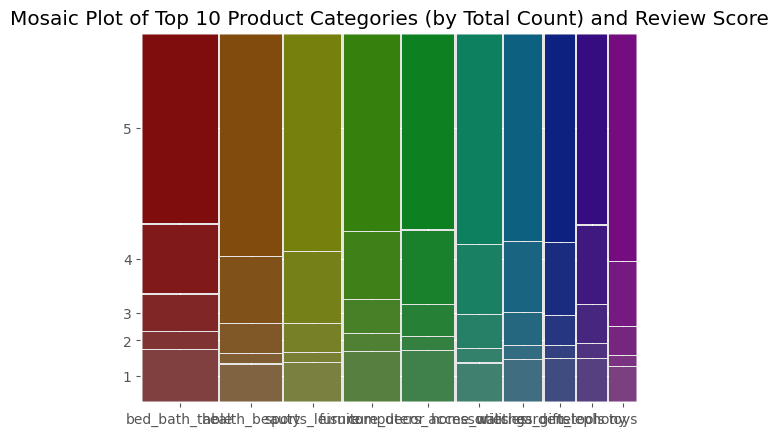

In [91]:
from statsmodels.graphics.mosaicplot import mosaic
# 변수들의 총 합을 기준으로 상위 10개 변수 선택
top_10_categories = crosstab.sum(axis=1).nlargest(10).index
crosstab_top_10 = crosstab.loc[top_10_categories]

# 상위 10개의 카테고리만 카이제곱 검정
chi2, p, dof, expected = stats.chi2_contingency(crosstab_top_10)

# 결과 출력
print('카이제곱 통계량:', chi2)
print('p-값:', p)
print('자유도:', dof)
print(crosstab_top_10)

# Mosaic plot 그리기
plt.figure(figsize=(10, 6))
mosaic(crosstab_top_10.stack(), labelizer=lambda _: '')
plt.title('Mosaic Plot of Top 10 Product Categories (by Total Count) and Review Score')
plt.show()

## Customer_city와 Review_score와의 카이제곱 검정

In [92]:
# Customer_city와 Review_score와의 카이제곱 검정
crosstab = pd.crosstab(order_merge['Customer_city'], order_merge['Review_score'])
chi2, p, dof, expected = stats.chi2_contingency(crosstab)

# 결과 출력
print('카이제곱 통계량:', chi2)
print('p-값:', p)
print('자유도:', dof)
print(crosstab)

카이제곱 통계량: 22982.369570510607
p-값: 1.271213119604619e-269
자유도: 15888
Review_score         1  2  3  4  5
Customer_city                     
abadia dos dourados  0  0  0  0  3
abadiania            0  0  0  1  0
abaete               1  0  0  6  3
abaetetuba           3  0  1  2  5
abaiara              0  0  0  1  1
...                 .. .. .. .. ..
xinguara             2  0  3  0  5
xique-xique          0  1  0  0  2
zacarias             0  0  1  0  1
ze doca              2  0  2  0  1
zortea               0  0  1  0  1

[3973 rows x 5 columns]


## 상위 10개의 Customer_city와 Review_score와의 카이제곱 검정

카이제곱 통계량: 467.0417020060893
p-값: 2.1199265450625028e-76
자유도: 36
Review_score              1    2     3     4     5
Customer_city                                     
sao paulo              1595  493  1348  3108  9789
rio de janeiro         1203  300   550  1196  3972
belo horizonte          351   77   274   546  1684
brasilia                267   73   174   445  1221
curitiba                185   55   132   285   974
campinas                182   61   138   304   869
porto alegre            229   46   106   266   802
salvador                231   65   140   317   595
guarulhos                98   48   109   258   706
sao bernardo do campo    65   42    73   185   641


<Figure size 1000x600 with 0 Axes>

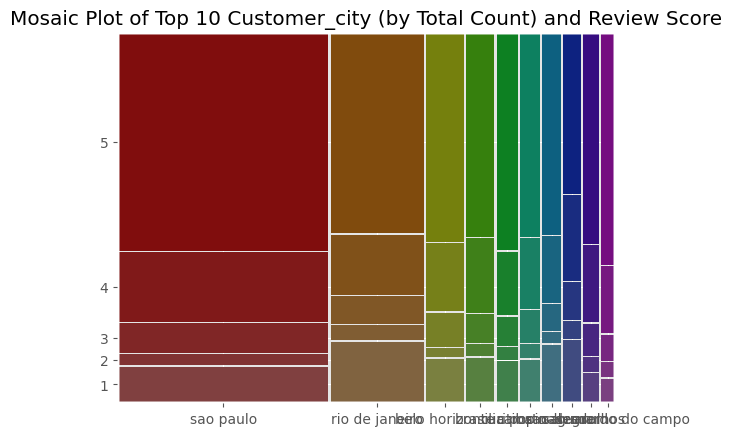

In [93]:
# 변수들의 총 합을 기준으로 상위 10개 변수 선택
top_10_categories = crosstab.sum(axis=1).nlargest(10).index
crosstab_top_10 = crosstab.loc[top_10_categories]

# 상위 10개의 카테고리만 카이제곱 검정
chi2, p, dof, expected = stats.chi2_contingency(crosstab_top_10)

# 결과 출력
print('카이제곱 통계량:', chi2)
print('p-값:', p)
print('자유도:', dof)
print(crosstab_top_10)

# Mosaic plot 그리기
plt.figure(figsize=(10, 6))
mosaic(crosstab_top_10.stack(), labelizer=lambda _: '')
plt.title('Mosaic Plot of Top 10 Customer_city (by Total Count) and Review Score')
plt.show()

## Price와 Review_score과의 ANOVA 검정

                    sum_sq        df         F    PR(>F)
Review_score  5.693721e+04       1.0  1.737992  0.187396
Residual      3.438329e+09  104954.0       NaN       NaN


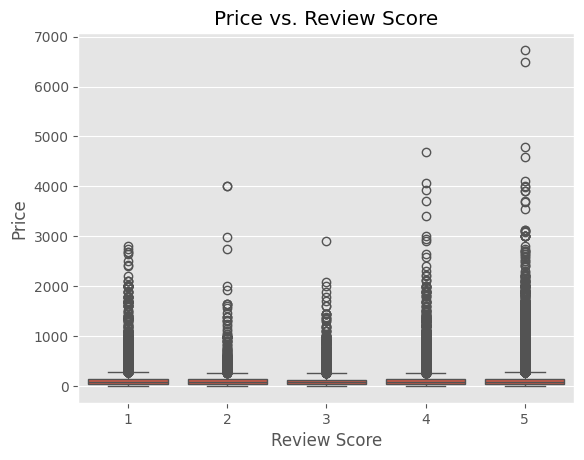

In [94]:
#  Price와 Review_score과의 ANOVA 검정

import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVA 검정
model = ols('Price ~ Review_score', data=order_merge).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# 시각화
sns.boxplot(x='Review_score', y='Price', data=order_merge)
plt.xlabel('Review Score')
plt.ylabel('Price')
plt.title('Price vs. Review Score')
plt.show()

## Payment_value와 Review Score과의 ANOVA 검정

                    sum_sq        df           F         PR(>F)
Review_score  5.109977e+07       1.0  721.406391  2.281657e-158
Residual      7.434264e+09  104954.0         NaN            NaN


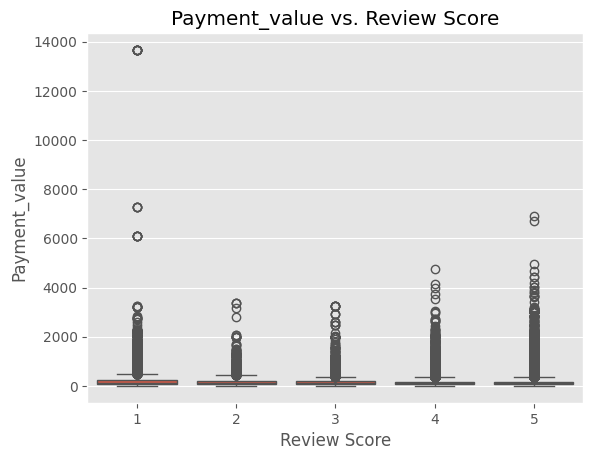

In [95]:
# Payment_value와 Review Score과의 ANOVA 검정
model = ols('Payment_value ~ Review_score', data=order_merge).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# 시각화
sns.boxplot(x='Review_score', y='Payment_value', data=order_merge)
plt.xlabel('Review Score')
plt.ylabel('Payment_value')
plt.title('Payment_value vs. Review Score')
plt.show()


## payment type과 review_score과의 카이제곱검정

카이제곱 통계량: 33.80873676594965
p-값: 0.000723001942999334
자유도: 12
Review_score     1     2     3      4      5
Payment_type                                
boleto        2404   668  1797   4047  11600
credit_card   9045  2633  6525  14853  44379
debit_card     116    48    96    221    776
voucher        657   239   509   1077   3266


<Figure size 1000x600 with 0 Axes>

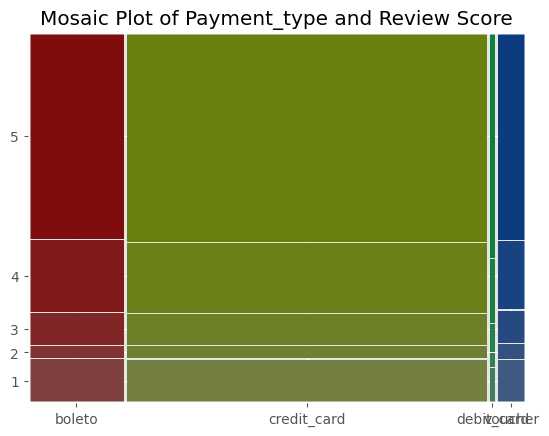

In [96]:
# payment type과 review_score과의 카이제곱검정

import pandas as pd
import matplotlib.pyplot as plt
# 카이제곱 검정
crosstab = pd.crosstab(order_merge['Payment_type'], order_merge['Review_score'])
chi2, p, dof, expected = stats.chi2_contingency(crosstab)

# 결과 출력
print('카이제곱 통계량:', chi2)
print('p-값:', p)
print('자유도:', dof)
print(crosstab)

# Mosaic plot 그리기
plt.figure(figsize=(10, 6))
mosaic(crosstab.stack(), labelizer=lambda _: '')
plt.title('Mosaic Plot of Payment_type and Review Score')
plt.show()


# 1번째 KPI : NPS

* Review score가 1점,2점 : 비추천 고객
* Review score가 3점 : 중립 고객
* Review score가 4점,5점 : 추천 고객

NPS Score : 추천 고객의 % - 비추천 고객의 % (-100 ~ 100)

전체 데이터의 평균 NPS Score :61.36762071725295

In [97]:

order_merge['Review_score_category'] = order_merge['Review_score'].apply(lambda x: '비추천 고객' if x <= 2 else '중립 고객' if x == 3 else '추천 고객')


## 추천, 비추천, 중립 고객 시각화

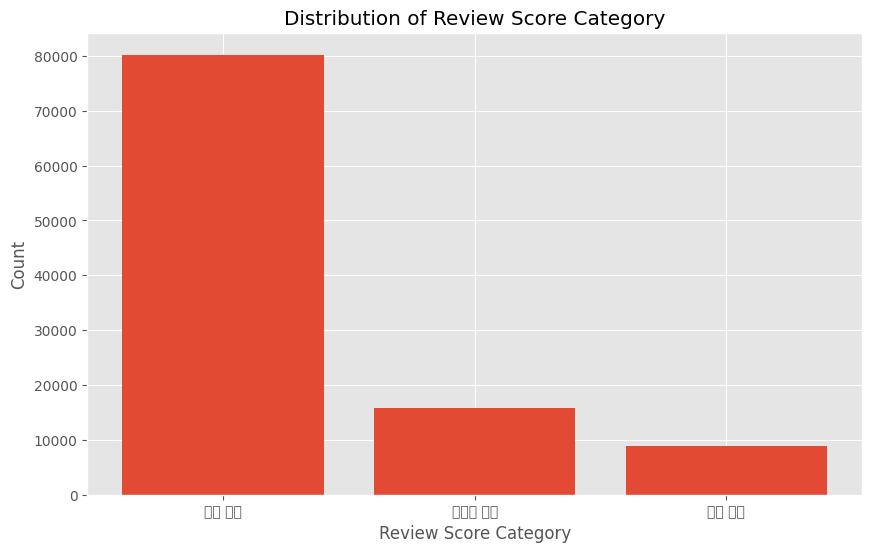

In [98]:
review_score_counts = order_merge['Review_score_category'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(review_score_counts.index, review_score_counts.values)
plt.xlabel('Review Score Category')
plt.ylabel('Count')
plt.title('Distribution of Review Score Category')
plt.show()


## 전체 데이터의 평균 NPS 출력

In [99]:
# 추천 고객과 비추천 고객의 수 계산
promoters = order_merge[order_merge['Review_score'] >= 4].shape[0]
detractors = order_merge[order_merge['Review_score'] <= 2].shape[0]

# NPS 계산
nps = (promoters - detractors) / order_merge.shape[0] * 100

# 결과 출력
print("NPS:", nps)


NPS: 61.36762071725295


## 월별 NPS 계산, 시각화

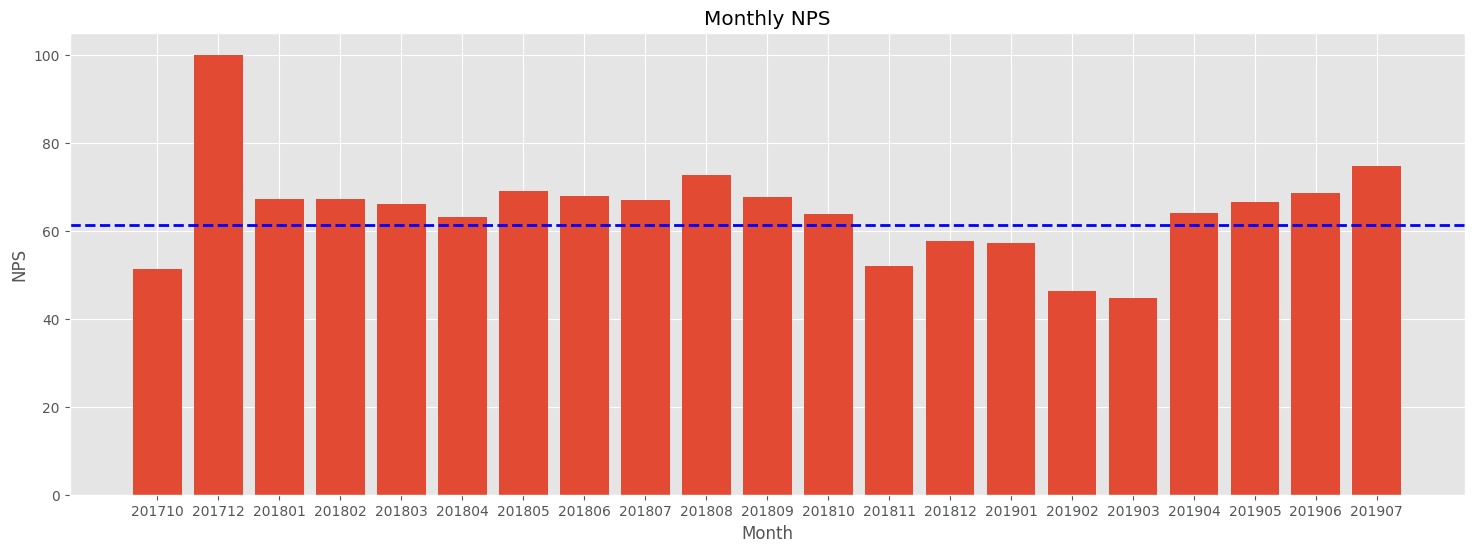

In [100]:
# 월별 NPS 계산
monthly_nps = (
    order_merge.groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.strftime('%Y%m'))
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge.groupby(pd.to_datetime(order_merge['Order_purchase_timestamp']).dt.strftime('%Y%m')).size()
    * 100
)

# 시각화
plt.figure(figsize=(18, 6))
plt.bar(monthly_nps.index, monthly_nps.values)
# 전체 평균 NPS 선 추가
plt.axhline(y=61.36762071725295, color='blue', linestyle='dashed', linewidth=2)

plt.xlabel('Month')
plt.ylabel('NPS')
plt.title('Monthly NPS')
plt.show()


## Customer_city별 NPS 계산, 시각화

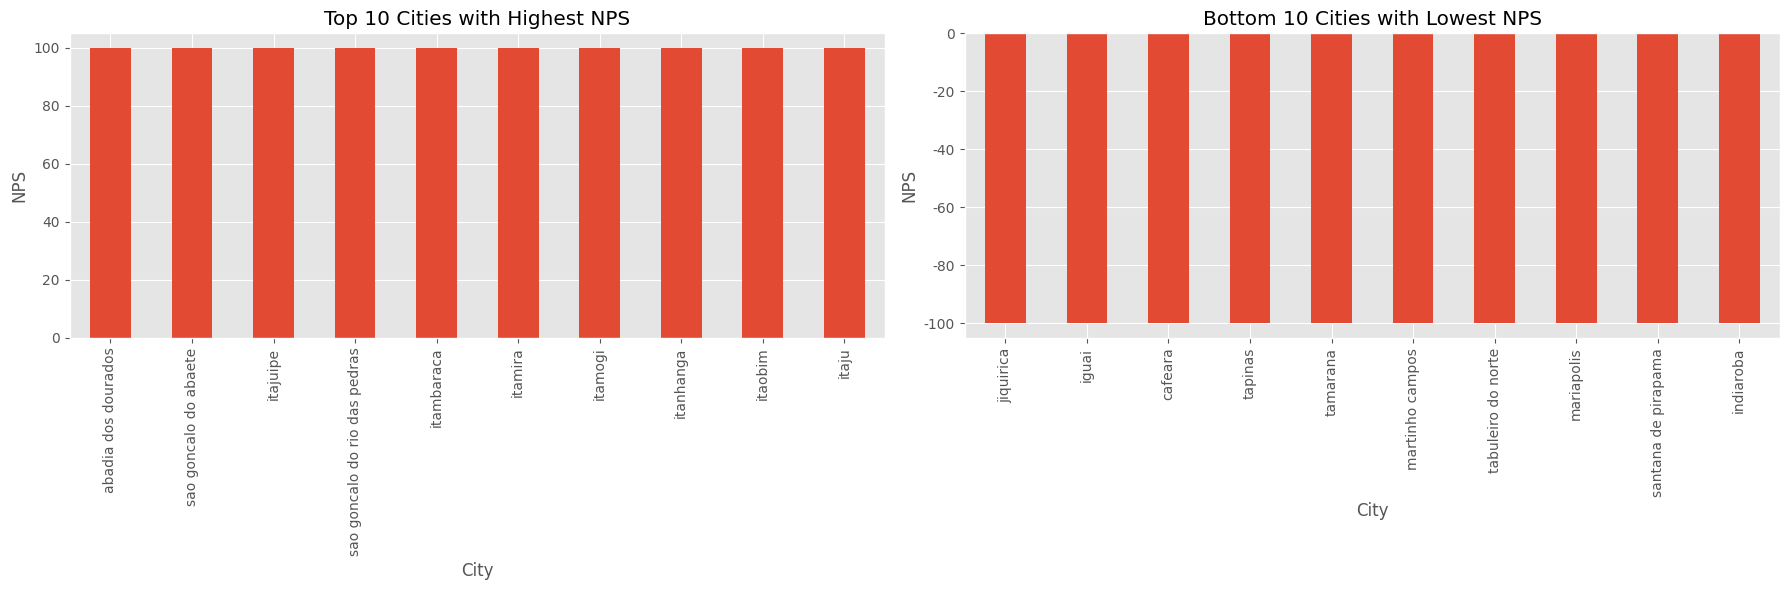

In [101]:
# Customer_city별 NPS 계산
customer_city_nps = (
    order_merge.groupby('Customer_city')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge.groupby('Customer_city').size()
    * 100
)

# 상위 10개와 하위 10개 도시 선택
top_10_cities = customer_city_nps.sort_values(ascending=False).head(10)
bottom_10_cities = customer_city_nps.sort_values().head(10)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 상위 10개 도시 NPS
top_10_cities.plot.bar(ax=axes[0])
axes[0].set_title('Top 10 Cities with Highest NPS')
axes[0].set_xlabel('City')
axes[0].set_ylabel('NPS')

# 하위 10개 도시 NPS
bottom_10_cities.plot.bar(ax=axes[1])
axes[1].set_title('Bottom 10 Cities with Lowest NPS')
axes[1].set_xlabel('City')
axes[1].set_ylabel('NPS')

plt.tight_layout()
plt.show()


## 판매량이 적어도 30개가 넘는 City만 추출하여 NPS 계산, 시각화


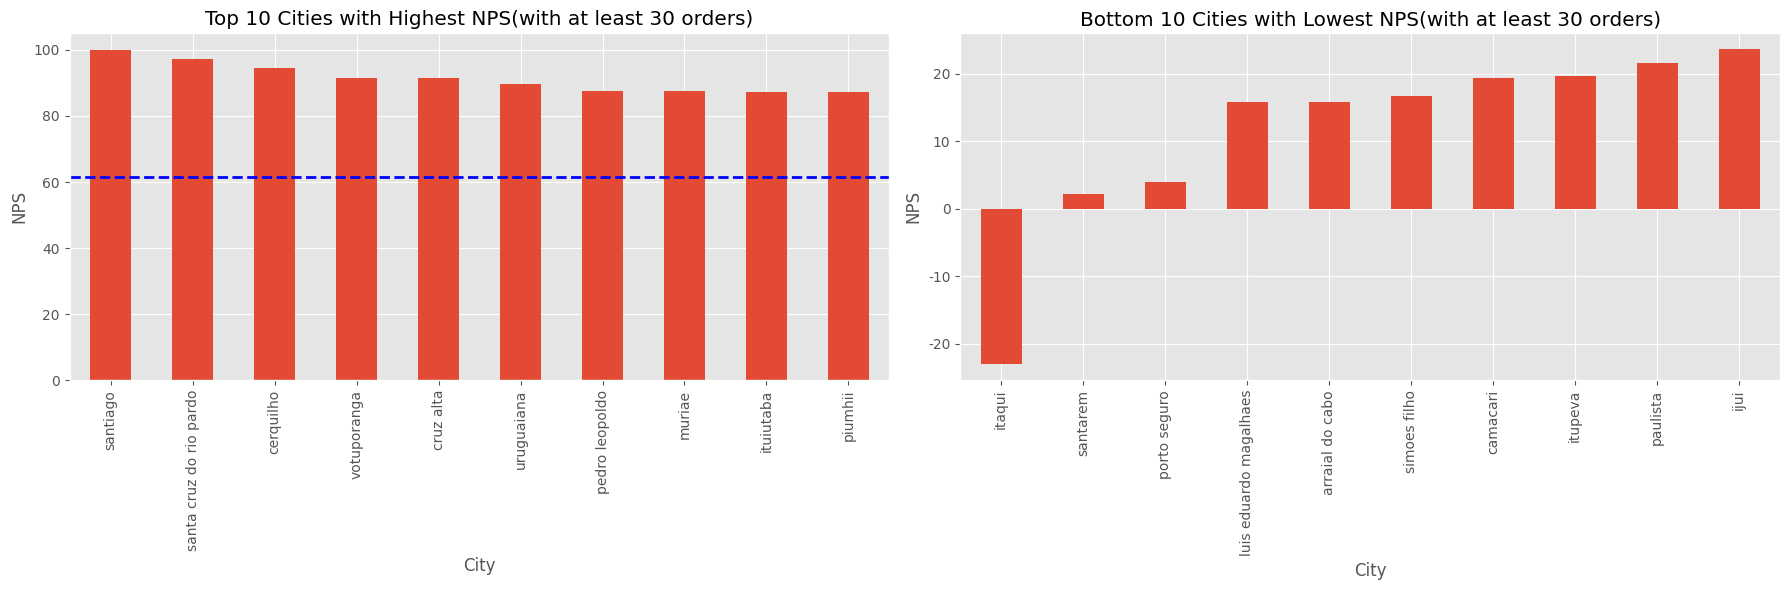

In [102]:
# 판매량이 적어도 30개가 넘는 City만 추출
city_counts = order_merge['Customer_city'].value_counts()
valid_cities = city_counts[city_counts >= 30].index

# City가 유효한 데이터만 추출
order_merge_filtered = order_merge[order_merge['Customer_city'].isin(valid_cities)]

# Customer_city별 NPS 계산
customer_city_nps = (
    order_merge_filtered.groupby('Customer_city')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge_filtered.groupby('Customer_city').size()
    * 100
)

# 상위 10개와 하위 10개 도시 선택
top_10_cities = customer_city_nps.sort_values(ascending=False).head(10)
bottom_10_cities = customer_city_nps.sort_values().head(10)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 전체 평균 NPS 선 추가
axes[0].axhline(y=61.36762071725295, color='blue', linestyle='dashed', linewidth=2)

# 상위 10개 도시 NPS
top_10_cities.plot.bar(ax=axes[0])
axes[0].set_title('Top 10 Cities with Highest NPS(with at least 30 orders)')
axes[0].set_xlabel('City')
axes[0].set_ylabel('NPS')

# 하위 10개 도시 NPS
bottom_10_cities.plot.bar(ax=axes[1])
axes[1].set_title('Bottom 10 Cities with Lowest NPS(with at least 30 orders)')
axes[1].set_xlabel('City')
axes[1].set_ylabel('NPS')

plt.tight_layout()
plt.show()


### 유일하게 음수의 NPS값을 가지는 itaqui 도시의 카테고리별 판매량

In [103]:
order_merge[order_merge['Customer_city'] == 'itaqui']['Product_category_name'].value_counts()

Product_category_name
computers_accessories     15
luggage_accessories       12
furniture_decor            3
home_utilities             3
garden_tools               2
baby                       2
cool_stuff                 1
books_general_interest     1
Name: count, dtype: int64

## Product_category_name별 NPS 계산(상위 10개, 하위10개), 시각화

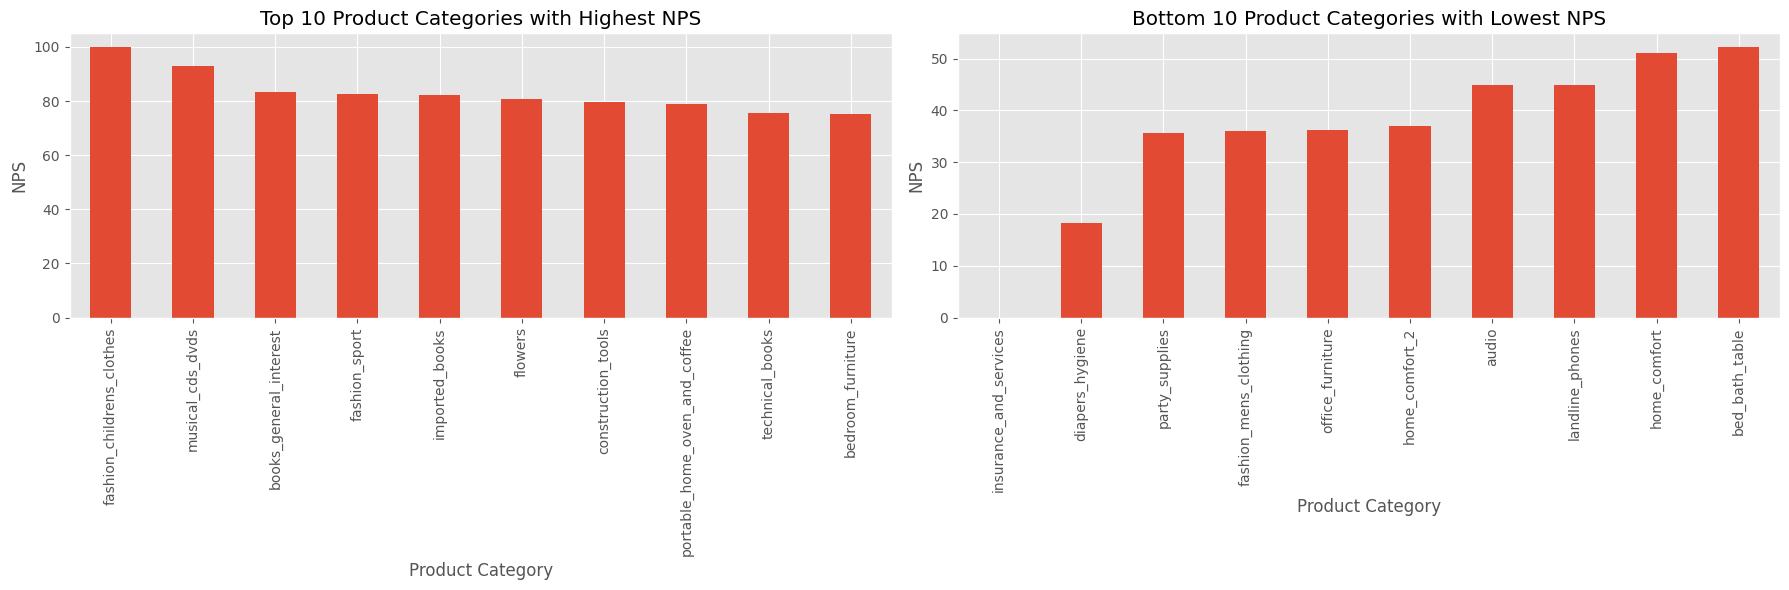

In [104]:
# Product_category_name별 NPS 계산
product_category_nps = (
    order_merge.groupby('Product_category_name')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge.groupby('Product_category_name').size()
    * 100
)

# 상위 10개와 하위 10개 카테고리 선택
top_10_categories = product_category_nps.sort_values(ascending=False).head(10)
bottom_10_categories = product_category_nps.sort_values().head(10)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 상위 10개 카테고리 NPS
top_10_categories.plot.bar(ax=axes[0])
axes[0].set_title('Top 10 Product Categories with Highest NPS')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('NPS')

# 하위 10개 카테고리 NPS
bottom_10_categories.plot.bar(ax=axes[1])
axes[1].set_title('Bottom 10 Product Categories with Lowest NPS')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('NPS')

plt.tight_layout()
plt.show()


## 판매량이 적어도 30개가 넘는 Product_category만 추출하여 NPS 계산, 시각화

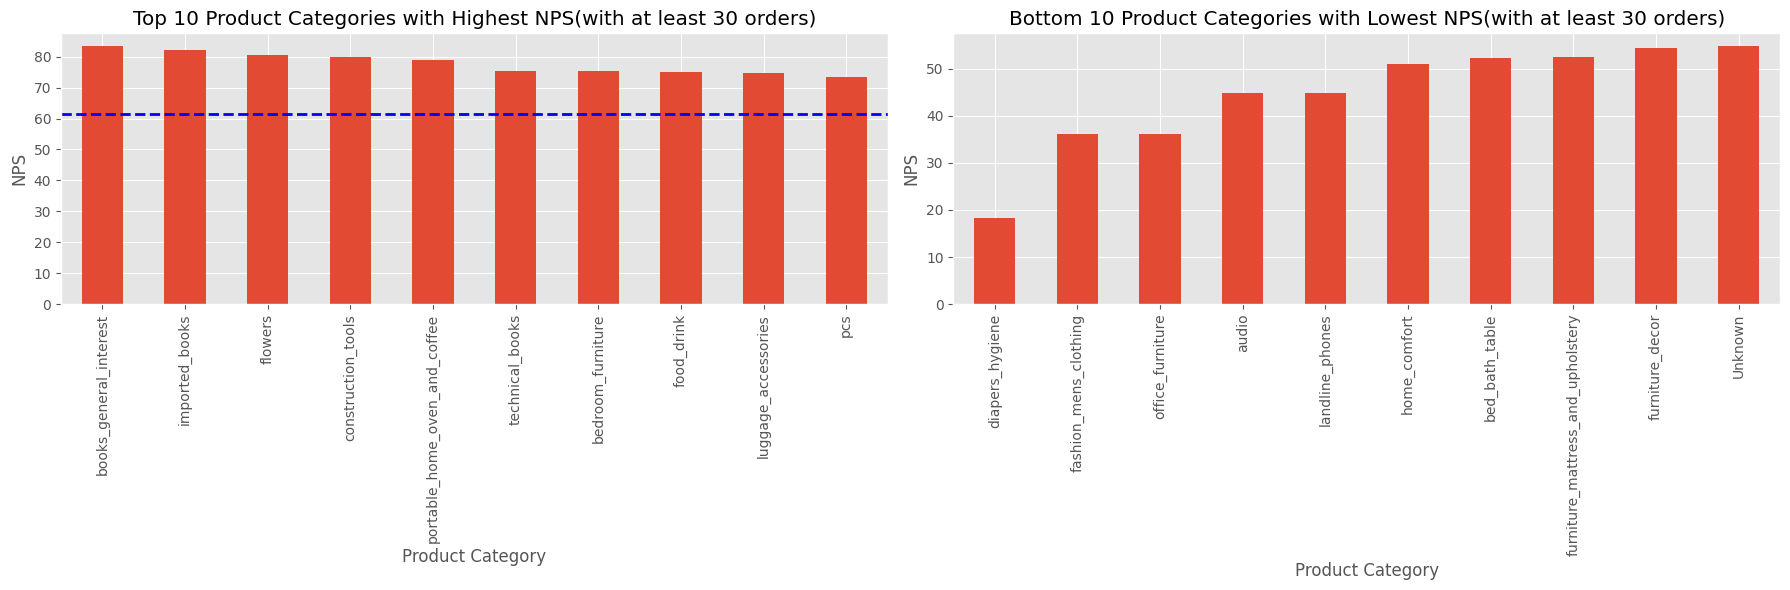

In [105]:
# 판매량이 적어도 30개가 넘는 Product_category만 추출
product_category_counts = order_merge['Product_category_name'].value_counts()
valid_categories = product_category_counts[product_category_counts >= 30].index

# Product_category가 유효한 데이터만 추출
order_merge_filtered = order_merge[order_merge['Product_category_name'].isin(valid_categories)]

# Product_category_name별 NPS 계산
product_category_nps = (
    order_merge_filtered.groupby('Product_category_name')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge_filtered.groupby('Product_category_name').size()
    * 100
)

# 상위 10개와 하위 10개 카테고리 선택
top_10_categories = product_category_nps.sort_values(ascending=False).head(10)
bottom_10_categories = product_category_nps.sort_values().head(10)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 전체 평균 NPS 선 추가
axes[0].axhline(y=61.36762071725295, color='blue', linestyle='dashed', linewidth=2)

# 상위 10개 카테고리 NPS
top_10_categories.plot.bar(ax=axes[0])
axes[0].set_title('Top 10 Product Categories with Highest NPS(with at least 30 orders)')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('NPS')

# 하위 10개 카테고리 NPS
bottom_10_categories.plot.bar(ax=axes[1])
axes[1].set_title('Bottom 10 Product Categories with Lowest NPS(with at least 30 orders)')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('NPS')

plt.tight_layout()
plt.show()


## Payment_type별 NPS 계산, 시각화

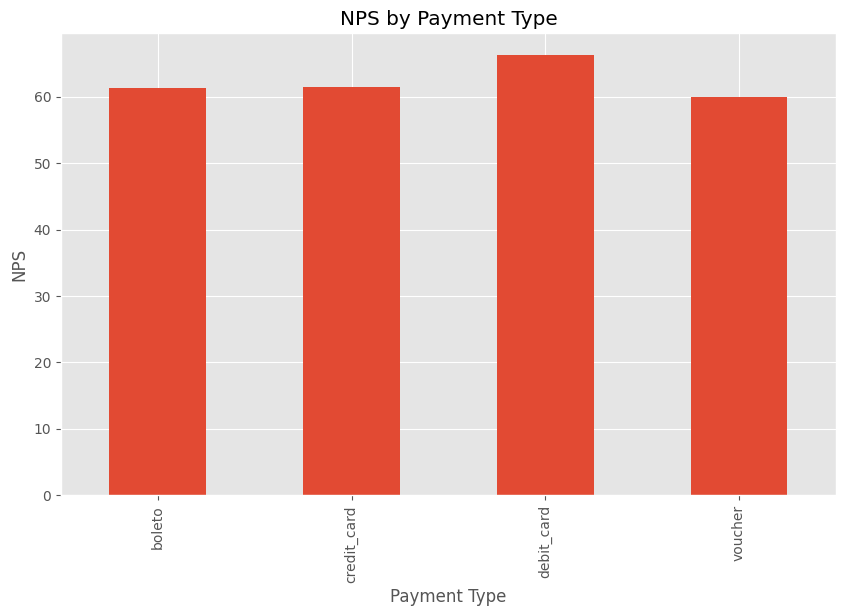

In [106]:
# Payment_type별 NPS 계산
payment_type_nps = (
    order_merge.groupby('Payment_type')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge.groupby('Payment_type').size()
    * 100
)

# 시각화
plt.figure(figsize=(10, 6))
payment_type_nps.plot.bar()
plt.xlabel('Payment Type')
plt.ylabel('NPS')
plt.title('NPS by Payment Type')
plt.show()


## delivery_delay별 NPS 계산, 시각화

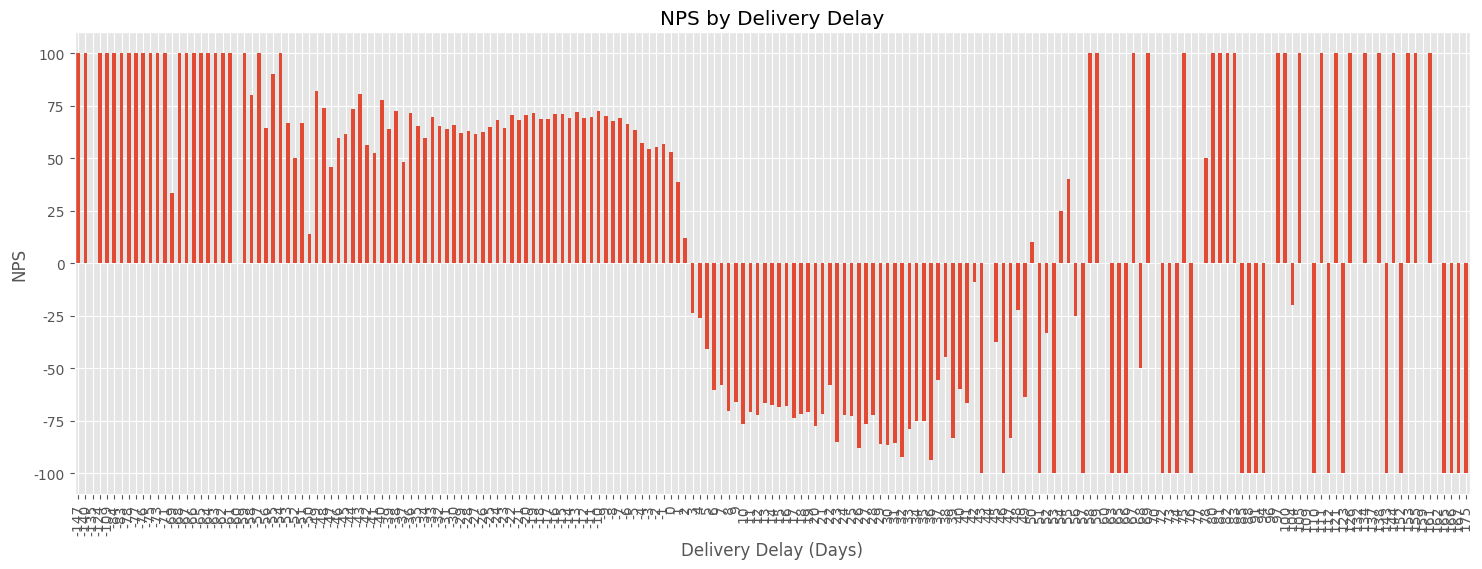

In [107]:
# delivery_delay별 NPS 계산
delivery_delay_nps = (
    order_merge.groupby('delivery_delay')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge.groupby('delivery_delay').size()
    * 100
)

# 시각화
plt.figure(figsize=(18, 6))
delivery_delay_nps.plot.bar()
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('NPS')
plt.title('NPS by Delivery Delay')
plt.show()


## 판매량이 30개 이상인 delivery_delay만 추출하여 시각화

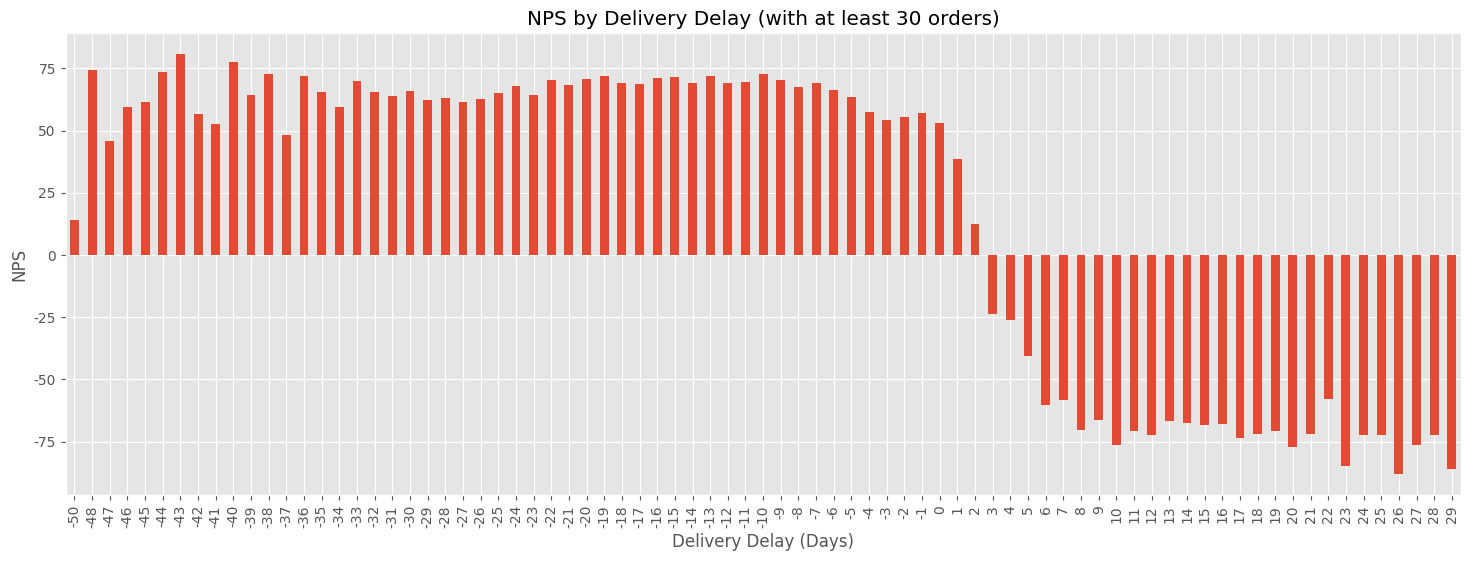

In [108]:
# 판매량이 30개 이상인 delivery_delay만 추출
delivery_delay_counts = order_merge['delivery_delay'].value_counts()
valid_delivery_delays = delivery_delay_counts[delivery_delay_counts >= 30].index

# delivery_delay가 유효한 데이터만 추출
order_merge_filtered = order_merge[order_merge['delivery_delay'].isin(valid_delivery_delays)]

# delivery_delay별 NPS 계산
delivery_delay_nps = (
    order_merge_filtered.groupby('delivery_delay')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / order_merge_filtered.groupby('delivery_delay').size()
    * 100
)

# 시각화
plt.figure(figsize=(18, 6))
delivery_delay_nps.plot.bar()
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('NPS')
plt.title('NPS by Delivery Delay (with at least 30 orders)')
plt.show()


## 고객 top10 도시별 NPS 계산

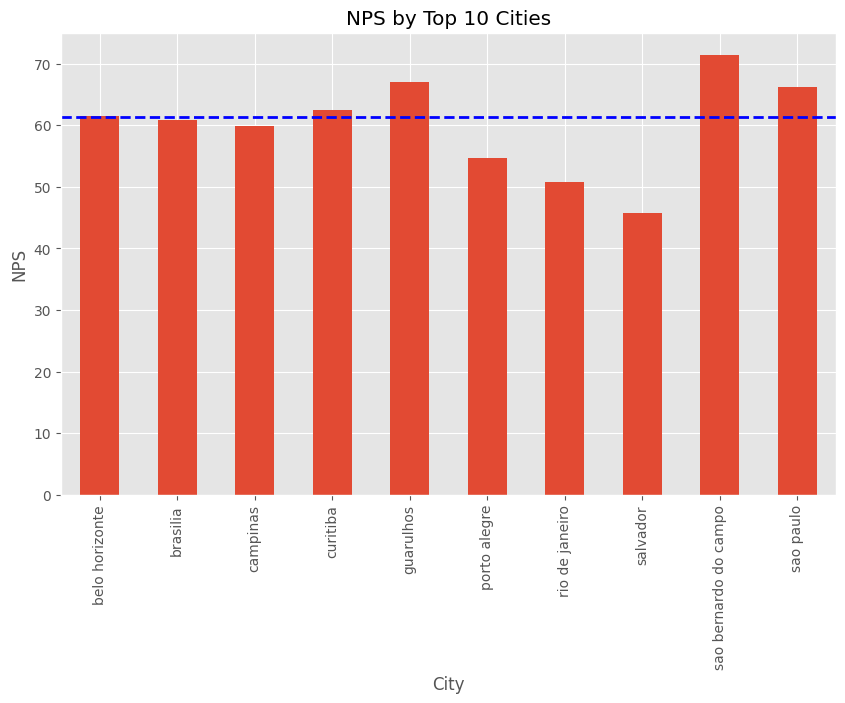

In [109]:
# 고객 top10 도시만 추출
top_10_cities = order_merge['Customer_city'].value_counts().head(10).index

# 고객 top10 도시만 추출한 데이터프레임 생성
top_10_cities_df = order_merge[order_merge['Customer_city'].isin(top_10_cities)]

# 고객 top10 도시별 NPS 계산
top_10_cities_nps = (
    top_10_cities_df.groupby('Customer_city')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / top_10_cities_df.groupby('Customer_city').size()
    * 100
)

# 시각화
plt.figure(figsize=(10, 6))
top_10_cities_nps.plot.bar()
# 전체 평균 NPS 선 추가
plt.axhline(y=61.36762071725295, color='blue', linestyle='dashed', linewidth=2)

plt.xlabel('City')
plt.ylabel('NPS')
plt.title('NPS by Top 10 Cities')
plt.show()


## 고객 top10 카테고리별 NPS 계산

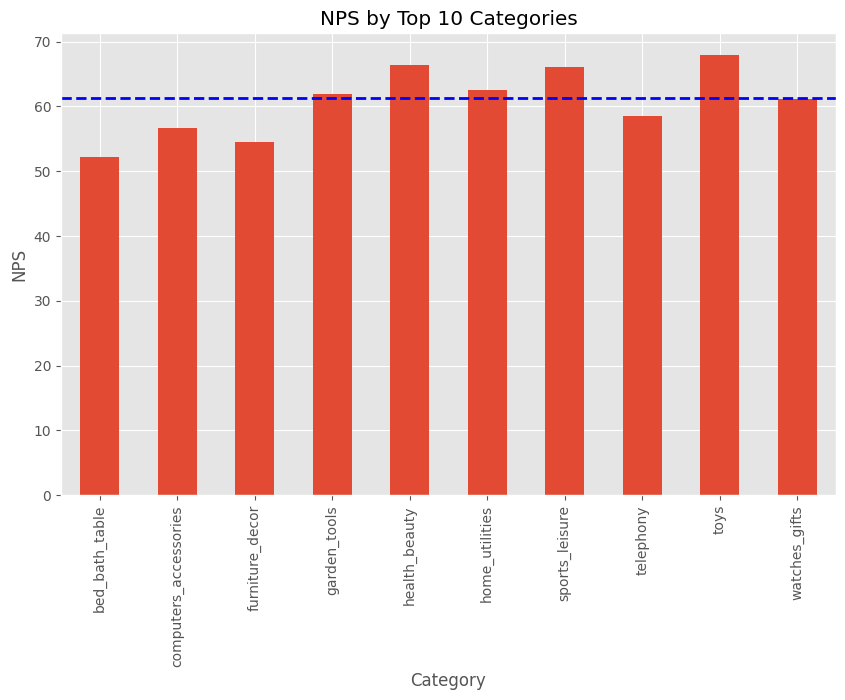

In [110]:
# 고객 top10 카테고리만 추출
top_10_categories = order_merge['Product_category_name'].value_counts().head(10).index

# 고객 top10 카테고리만 추출한 데이터프레임 생성
top_10_categories_df = order_merge[order_merge['Product_category_name'].isin(top_10_categories)]

# 고객 top10 카테고리별 NPS 계산
top_10_categories_nps = (
    top_10_categories_df.groupby('Product_category_name')
    .apply(lambda df: (df['Review_score'] >= 4).sum() - (df['Review_score'] <= 2).sum())
    / top_10_categories_df.groupby('Product_category_name').size()
    * 100
)

# 시각화
plt.figure(figsize=(10, 6))
top_10_categories_nps.plot.bar()
# 전체 평균 NPS 선 추가
plt.axhline(y=61.36762071725295, color='blue', linestyle='dashed', linewidth=2)

plt.xlabel('Category')
plt.ylabel('NPS')
plt.title('NPS by Top 10 Categories')
plt.show()


# 2번째 KPI : RFM

RFM분석은 고객의 구매이력을 통하여 최근성, 빈도, 구매금액을 분석한다. 이를 통해 불특정 고객들 사이에서 잠재적 가치가 높은 고객의 선별이 가능하다.

## 데이터 전처리

In [111]:
# 날짜/시간 형식으로 변환
order_merge['Order_purchase_timestamp'] = pd.to_datetime(order_merge['Order_purchase_timestamp'])
order_merge['Order_delivered_customer_date'] = pd.to_datetime(order_merge['Order_delivered_customer_date'])
order_merge['Order_estimated_delivery_date'] = pd.to_datetime(order_merge['Order_estimated_delivery_date'])

## Recency(최근성 데이터)

- 고객별 마지막 구입 날짜 중 가장 마지막 날 : 2019-07-30
- Recency = (2019-07-30) - (고객별 마지막 구입 날짜)

In [112]:
# 가장 최근에 거래한 날짜 추출
recency_df = order_merge.groupby(by='Customer_id', as_index=False)['Order_purchase_timestamp'].max() # 각 customer_id별로 가장 마지막에 구입한 날짜를 정리
recency_df.rename(columns={'Order_purchase_timestamp':'Last_purchase'}, inplace=True) # 마지막 구입한 날짜를 의미하는 Last_purchase로 컬럼명 수정
recency_df['Last_purchase'] = recency_df['Last_purchase'].dt.date # 각 customer_id 마다의 마지막 구입 날짜를 datetime 형태로 변환

# 주어진 데이터에서 가장 최근까지 거래된 날짜와 customer_id별 마지막 거래 날짜의 차를 측정
recent_date = recency_df['Last_purchase'].max() # 2019-07-30이 가장 최근까지 거래된 날짜임을 확인
recency_df['Recency'] = recency_df['Last_purchase'].apply(lambda x: (recent_date - x).days) # ex. 2019-07-30과 2018-05-16과의 차이는 440일
recency_df.head()

,Customer_id,Last_purchase,Recency
0,CUSTOMER_00000,2018-05-16,440
1,CUSTOMER_00001,2019-01-12,199
2,CUSTOMER_00002,2019-05-19,72
3,CUSTOMER_00003,2019-03-13,139
4,CUSTOMER_00004,2018-09-14,319


## Frequency(구입 빈도 수 데이터)

In [113]:
# 물건 구매 빈도 측정
frequency_df = order_merge.groupby('Customer_id')['Order_id'].nunique().reset_index() # 각 customer_id별 order_id의 수를 측정
frequency_df.rename(columns={'Order_id':'Frequency'}, inplace=True) # 물건의 구입 횟수를 의미하는 frequency 컬럼 생성
frequency_df.head()

,Customer_id,Frequency
0,CUSTOMER_00000,1
1,CUSTOMER_00001,1
2,CUSTOMER_00002,1
3,CUSTOMER_00003,1
4,CUSTOMER_00004,1


## Monetary(구매 가치 데이터)

In [114]:
# 얼마나 구매했는가 확인
monetary_df = order_merge.groupby('Customer_id')['Payment_value'].sum().reset_index()# 각 customer_id별 payment_value 합 측정
monetary_df.rename(columns={'Payment_value' : 'Monetary'}, inplace=True) # 물건의 구매 횟수를 의미하는 monetary 컬럼 생성
monetary_df.head()

,Customer_id,Monetary
0,CUSTOMER_00000,146.87
1,CUSTOMER_00001,335.48
2,CUSTOMER_00002,157.73
3,CUSTOMER_00003,173.30
4,CUSTOMER_00004,282.21


## RFM 데이터 프레임 생성

In [115]:
rf = pd.merge(recency_df, frequency_df, on='Customer_id') # recency와 frequency를 합쳐 rf라는 데이터 프레임 생성
rfm = pd.merge(rf, monetary_df, on='Customer_id') # rf와 monetary_df를 합쳐 rfm 데이터 프레임 생성
rfm.drop('Last_purchase', axis=1, inplace=True) # 가장 마지막 구매 날짜는 필요 없으니 제거
rfm.head()

,Customer_id,Recency,Frequency,Monetary
0,CUSTOMER_00000,440,1,146.87
1,CUSTOMER_00001,199,1,335.48
2,CUSTOMER_00002,72,1,157.73
3,CUSTOMER_00003,139,1,173.30
4,CUSTOMER_00004,319,1,282.21


## RFM 데이터 시각화

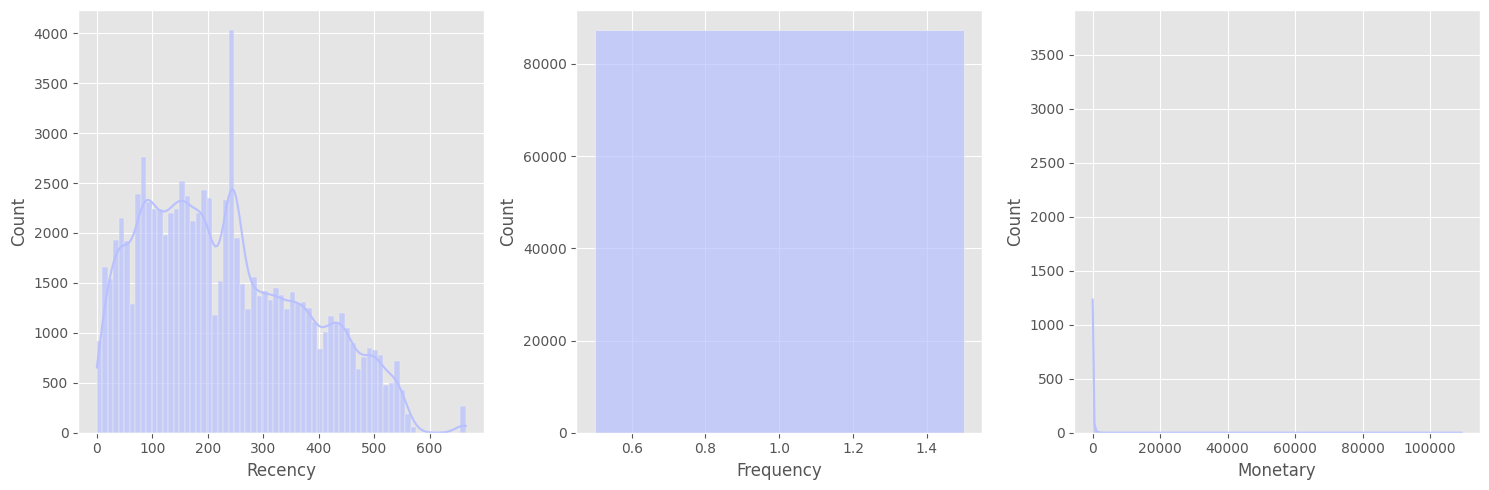

In [116]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(15, 5))
for i, column in enumerate(rfm.columns[1:], 1):  # rfm의 모든 컬럼을 돌면서 histplot을 생성
    plt.subplot(1, 3, i)
    sns.histplot(rfm[column], color='#b8c0ff', kde=True, alpha=0.7)
    plt.xlabel(column)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

- monetary의 histplot 확인 결과 너무 작은 값이 뭉쳐져 있는 것처럼 보이는 것을 확인
- 그러나 recency와 frequency는 log에 영향을 받지 않기 위해 변환되는 컬럼은 monetary만으로 한정
- log를 취해주며 좁게 뭉쳐진 monetary의 분포를 파악해보기로 함

In [117]:
rfm_log = rfm.copy()
for i in rfm.columns[3:]:
    rfm_log[i] = np.log10(rfm_log[i])

## RFM 데이터 시각화(log 스케일 적용)

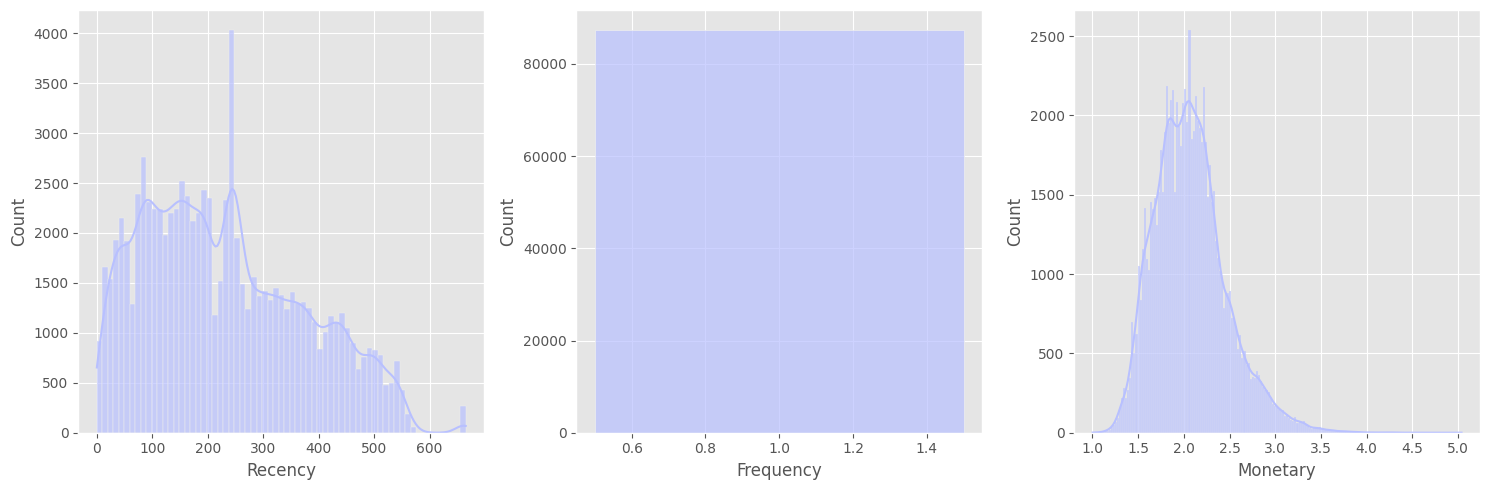

In [118]:
plt.figure(figsize=(15, 5))
for i, column in enumerate(rfm_log.columns[1:], 1):
    plt.subplot(1, 3, i)
    sns.histplot(rfm_log[column], color='#b8c0ff', kde=True, alpha=0.7)
    plt.xlabel(column)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3D 산점도 시각화

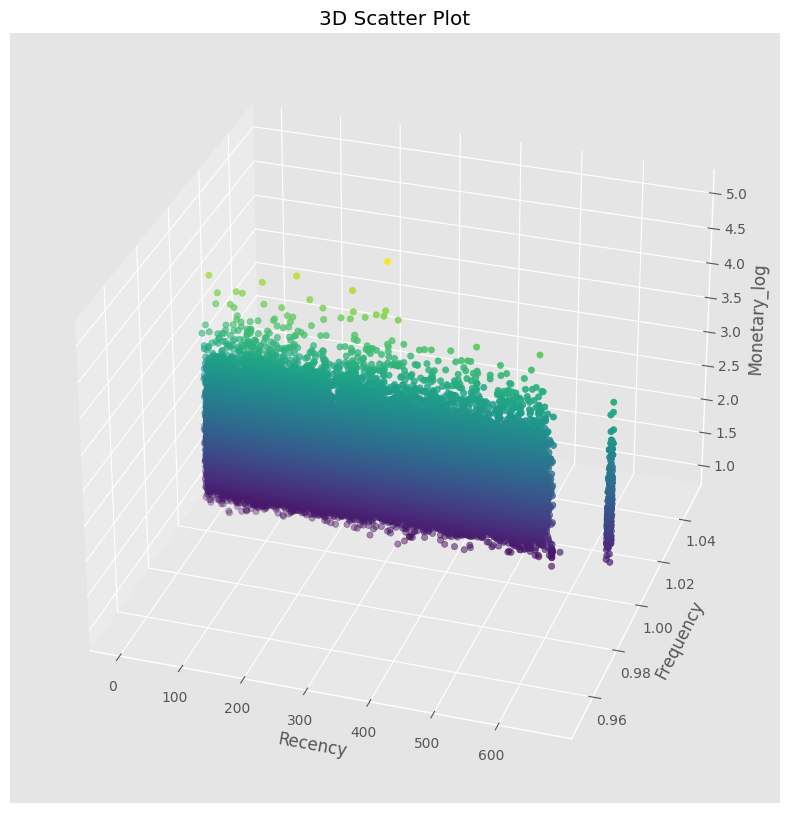

In [119]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_log['Recency'], rfm_log['Frequency'], rfm_log['Monetary'],  c=rfm_log['Monetary'], cmap='viridis', marker='o', label='Data Points')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary_log')
ax.set_title('3D Scatter Plot')

# 그래프 각도 변경
ax.view_init(azim=288)

plt.show()

## MinMaxScaler 적용

In [120]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(rfm_log.drop("Customer_id", axis=1))
rfm_scaled = scaler.transform(rfm_log.drop("Customer_id", axis=1))

rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_log.columns[1:])
rfm_scaled

,Recency,Frequency,Monetary
0,0.661654,0.0,0.288406
1,0.299248,0.0,0.377297
2,0.108271,0.0,0.296083
3,0.209023,0.0,0.306214
4,0.479699,0.0,0.358690
...,...,...,...
87343,0.171429,0.0,0.234234
87344,0.175940,0.0,0.274495
87345,0.169925,0.0,0.184721
87346,0.404511,0.0,0.458139


## K-Means Clustering

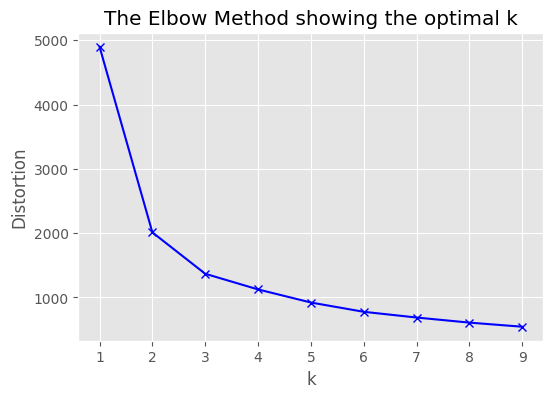

In [121]:
from sklearn.cluster import KMeans
distortions = []

k_range = range(1,10)
for i in k_range:
    kmeanModel = KMeans(n_clusters=i)
    kmeanModel.fit(rfm_scaled)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

- k=3이 적절한 k값으로 판단

In [122]:
model_km = KMeans(n_clusters=3, random_state=5)
y_km = model_km.fit_predict(rfm_scaled)
rfm['Cluster'] = model_km.labels_

## 자체 RFM 가중치 제작

- k-means 클러스터링을 통해 최적의 k를 찾아냈으니 이제는 R, F, M의 표준편차를 평균으로 나누어 CV를 산출
- 그리고 CV를 최소화하는 값을 찾아 전체 CV의 합으로 다시 나누어 가중치를 산출
- 모든 가중치츼 합을 1로 만들기 위해 w1, w2, w3 각각 모두 더한 값으로 나누어 최종 가중치 산출
- R, F, M의 표준편차를 평균으로 나누어 CV 계산

In [123]:
cv_r = rfm.groupby('Cluster')['Recency'].std() / rfm.groupby('Cluster')['Recency'].mean()
cv_f = rfm.groupby('Cluster')['Frequency'].std() / rfm.groupby('Cluster')['Frequency'].mean()
cv_m = rfm.groupby('Cluster')['Monetary'].std() / rfm.groupby('Cluster')['Monetary'].mean()

# CV를 최소로 하는 CVrn, CVfn, CVmn 찾기
cvrn = cv_r.idxmin()
cvfn = cv_f.idxmin()
cvmn = cv_m.idxmin()

# CVrn, CVfn, CVmn을 전체 CV의 합으로 나누어 w1, w2, w3 계산
total_cv = cv_r.sum() + cv_f.sum() + cv_m.sum()
w1 = cv_r[cvrn] / total_cv
w2 = cv_f[cvfn] / total_cv
w3 = cv_m[cvmn] / total_cv

# 모든 가중치의 합을 1로 만들기 위해 정규화
total_w = w1 + w2 + w3
W1 = w1 / total_w
W2 = w2 / total_w
W3 = w3 / total_w

print("최종 가중치 W1:", W1)
print("최종 가중치 W2:", W2)
print("최종 가중치 W3:", W3)

최종 가중치 W1: 0.07323298354133959
최종 가중치 W2: 0.0
최종 가중치 W3: 0.9267670164586604


## 최종 RFM 모델 설계

- 일반적으로 RFM 분석은 점수를 기준으로 등급을 나누게 됨
- 보통 20%씩 나누는 5등급, 10%씩 나누는 10등급이 많이 사용됨
- 여기서는 20%씩 나누는 5등급으로 진행해보기로 함

In [124]:
rfm['RFM_Score'] = W1 * rfm['Recency'] + W2 * rfm['Frequency'] + W3 * rfm['Monetary']
rfm['RFM_Rank'] = 5 - pd.qcut(rfm['RFM_Score'], q=5, labels=False)
rfm.sort_values('RFM_Rank').head(5)

,Customer_id,Recency,Frequency,Monetary,Cluster,RFM_Score,RFM_Rank
58379,CUSTOMER_58881,173,1,289.04,1,280.542045,1
60912,CUSTOMER_61439,378,1,226.22,2,237.335302,1
60916,CUSTOMER_61443,406,1,417.04,2,416.231508,1
60918,CUSTOMER_61445,209,1,292.56,1,286.440652,1
13281,CUSTOMER_13403,446,1,377.98,2,382.961308,1


## ANOVA 분산 검정

#### F-statistic (F)
- F 값이 크면 집단 간 차이가 크다는 것을 의미

#### p-value (PR(>F)): 0.0
- 귀무 가설이 맞다는 전제 하에 현재 결과를 얻을 확률
- p-value가 작으면 귀무 가설을 기각할 수 있는 증거가 강하다는 것을 의미

In [125]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Recency에 대한 ANOVA
anova_recency = ols('Recency ~ C(RFM_Rank)', data=rfm).fit()
anova_recency = sm.stats.anova_lm(anova_recency, typ=2)

# Frequency에 대한 ANOVA
anova_frequency = ols('Frequency ~ C(RFM_Rank)', data=rfm).fit()
anova_frequency = sm.stats.anova_lm(anova_frequency, typ=2)

# Monetary에 대한 ANOVA
anova_monetary = ols('Monetary ~ C(RFM_Rank)', data=rfm).fit()
anova_monetary = sm.stats.anova_lm(anova_monetary, typ=2)

print('Recency ANOVA')
display(anova_recency)

print('Frequency ANOVA')
display(anova_frequency)

print('Monetary ANOVA')
display(anova_monetary)


Recency ANOVA


,sum_sq,df,F,PR(>F)
C(RFM_Rank),5.987524e+07,4.0,752.118787,0.0
Residual,1.738317e+09,87343.0,NaN,NaN


Frequency ANOVA


,sum_sq,df,F,PR(>F)
C(RFM_Rank),8.424849e-27,4.0,374.049295,5.289961e-320
Residual,4.918146e-25,87343.0,NaN,NaN


Monetary ANOVA


,sum_sq,df,F,PR(>F)
C(RFM_Rank),4.145316e+09,4.0,3023.787265,0.0
Residual,2.993467e+10,87343.0,NaN,NaN


## 고객별 등급 명칭 부여 및 등급별 R, F, M 평균, 빈도수 확인

In [126]:
# RFM_Rank 등급별 명칭 변경
rfm['Customer_Rank'] = rfm['RFM_Rank'].map({1: 'Diamond', 2: 'Platinum', 3: 'Gold',
                                            4: 'Silver', 5: 'Bronze'})

# rfm_rank 별로 그룹화하여 평균 계산
rfm_rank_summary = rfm.groupby('Customer_Rank').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_id': 'count'
}).reset_index()

# 컬럼명 변경
rfm_rank_summary.columns = ['Customer_Rank', 'Recency_mean', 'Frequency_mean', 'Monetary_mean', 'Count']

# 원하는 등급 순서 정의
order = ['Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']

# 등급을 원하는 순서로 재정렬
rfm_rank_summary = rfm_rank_summary.set_index('Customer_Rank').reindex(order).reset_index()


# 결과 출력
rfm_rank_summary

,Customer_Rank,Recency_mean,Frequency_mean,Monetary_mean,Count
0,Diamond,240.731025,1.0,632.045241,17470
1,Platinum,243.274543,1.0,174.717339,17469
2,Gold,243.169482,1.0,110.056440,17465
3,Silver,246.769887,1.0,70.003591,17474
4,Bronze,178.209960,1.0,41.416556,17470


# 3번째 KPI : RCI

ABC 분석(ABC Analysis)을 기반으로 카테고리별 매출 기여도를 수치화하여 상대적으로 중요한 카테고리를 선정하는 커스텀 KPI

## 사전 설정

그룹 기준치 설정  
* 일반적인 쇼핑몰 매출 기여도 분석과 같이 누적 매출 70% ,90%, 100%로 나누어 A,B,C 그룹 설정
  
매출액 계산법

택배사와 계약 x
* 매출액 = 판매가 + 화물비용  

택배사와 계약 o  
* 매출액 = 판매가

해당 분석은 택배사와 계약했다고 설정

## 데이터 전처리

In [127]:
# 데이터 분리 후 합치기

order_merge = pd.merge(order_items, product , on = 'Product_id' , how='inner')
order_merge = pd.merge(order_merge, orders, on = 'Order_id' , how='inner')

order_merge['Order_purchase_timestamp'] = pd.to_datetime(order_merge['Order_purchase_timestamp'])

# 시간 순서대로 정렬
order_merge = order_merge.sort_values(by='Order_purchase_timestamp')

# 년 , 월 컬럼 추가
order_merge['year'] = order_merge['Order_purchase_timestamp'].dt.year
order_merge['month'] = order_merge['Order_purchase_timestamp'].dt.month

# 초기 불균형 데이터 2017년 제외 데이터
# order_merge = order_merge[order_merge['year'] != 2017]

# 확인
order_merge.head(1)

,Order_id,Order_item_id,Product_id,Seller_id,Price,Freight_value,Product_category_name,Product_weight_g,Product_length_cm,Product_height_cm,Product_width_cm,Customer_id,Order_status,Order_purchase_timestamp,Order_delivered_carrier_date,Order_delivered_customer_date,Order_estimated_delivery_date,year,month
71738,ORDER_82627,1,PRODUCT_13424,SELLER_1784,29.9,15.56,watches_gifts,300.0,16.0,16.0,16.0,CUSTOMER_34191,delivered,2017-10-03 09:44:50,2017-10-23 14:02:13,2017-10-26 14:02:13,2017-10-27,2017,10


## ABC 분석 함수

### 데이터 시각화를 위한 정규화 함수 ##

In [128]:
def normal_for_v(data,standard):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    # 시각화 그래프의 Y축 범위 = standard
    normalized_data = (data - min_val) / (max_val - min_val) * standard
    return normalized_data

### 카테고리별 매출액 함수(전체)

In [129]:
# 주요 카테고리 시각화 및 A,B 그룹 출력 함수

def total(data):

    # 데이터 집계
    category=data[['Order_purchase_timestamp','year','month','Product_category_name','Price']]
    category_s=category
    cat_data= category_s.groupby('Product_category_name',as_index=False)['Price'].sum()

    #정렬
    cat_data= cat_data.sort_values(by='Price', ascending=False)

    # 매출 비율, 누적 비율 컬럼 추가
    cat_data['ratio']=cat_data['Price']/ cat_data['Price'].sum()
    cat_data['cum_ratio'] = cat_data['ratio'].cumsum()
    cat_data=cat_data.reset_index(drop=True)

    # 시각화를 위한 누적비 정규화
    y_max = np.max(cat_data['Price'])
    # 데이터 시각화를 위한 정규화 함수 사용
    for_visual=normal_for_v(cat_data['cum_ratio'],y_max)

    # 그래프 설정
    plt.figure(figsize=(20,8))

    # 막대 그래프 그리기
    for i in range(len(cat_data)):
        # 70% 지점까지의 막대는 연한 녹색으로
        if cat_data['cum_ratio'][i] <= 0.7:
            plt.bar(cat_data['Product_category_name'][i], cat_data['Price'][i], color='lightgreen')
        # 90% 이후의 막대는 빨간색으로
        elif cat_data['cum_ratio'][i] > 0.9:
            plt.bar(cat_data['Product_category_name'][i], cat_data['Price'][i], color='red')
        else:
            plt.bar(cat_data['Product_category_name'][i], cat_data['Price'][i], color='skyblue')
    plt.plot(cat_data['Product_category_name'], for_visual, color='orange',marker='o', linestyle='-')
    plt.xlabel('Category')
    plt.ylabel('revenue')
    plt.title(' Total ABC Analysis')
    plt.xticks(rotation=45)

    # 가로선만
    plt.grid(axis='y')
    plt.gca().yaxis.grid(True, linestyle='--', color='gray', alpha=0.5)

    # 꺽은선 그래프 값 표기
    for i in cat_data.index:
        plt.text(for_visual.index[i], for_visual[i], '{:.1f}%'.format(cat_data['cum_ratio'][i]*100), ha='center', va='bottom')

    plt.show()

    # 주요 품목 출력
    major_A=cat_data[cat_data['cum_ratio']<=0.7]
    major_B=cat_data[(cat_data['cum_ratio']>0.7)&(cat_data['cum_ratio']<=0.9)]
    A=[]
    B=[]
    for i in major_A.index:
        A.append(major_A['Product_category_name'][i])
    for i in major_B.index:
        B.append(major_B['Product_category_name'][i])
    print('A 그룹 품목\n', A)
    print('B 그룹 품목\n', B)

    return A, B


### 카테고리별 매출액 함수(분기별)

In [130]:
# 주요 카테고리 시각화 및 A,B 그룹 출력 함수

def quarter(data, year , quarter):

    # 분기 설정
    if quarter==1:
        q=[1,2,3]
    elif quarter==2:
        q=[4,5,6]
    elif quarter==3:
        q=[7,8,9]
    elif quarter==4:
        q=[10,11,12]

    # 데이터 집계
    category=data[['Order_purchase_timestamp','year','month','Product_category_name','Price']]
    category_s=category[(category['year']==year)&(category['month'].isin(q))]
    cat_data= category_s.groupby('Product_category_name',as_index=False)['Price'].sum()

    #정렬
    cat_data= cat_data.sort_values(by='Price', ascending=False)

    # 매출 비율, 누적 비율 컬럼 추가
    cat_data['ratio']=cat_data['Price']/ cat_data['Price'].sum()
    cat_data['cum_ratio'] = cat_data['ratio'].cumsum()
    cat_data=cat_data.reset_index(drop=True)

    # 시각화를 위한 누적비 정규화
    y_max = np.max(cat_data['Price'])
    # 데이터 시각화를 위한 정규화 함수
    for_visual=normal_for_v(cat_data['cum_ratio'],y_max)

    # 그래프 설정
    plt.figure(figsize=(20,8))
    for i in range(len(cat_data)):
        # 70% 지점까지의 막대는 연한 녹색으로
        if cat_data['cum_ratio'][i] <= 0.7:
            plt.bar(cat_data['Product_category_name'][i], cat_data['Price'][i], color='lightgreen')
        # 90% 이후의 막대는 빨간색으로
        elif cat_data['cum_ratio'][i] > 0.9:
            plt.bar(cat_data['Product_category_name'][i], cat_data['Price'][i], color='red')
        else:
            plt.bar(cat_data['Product_category_name'][i], cat_data['Price'][i], color='skyblue')
    plt.plot(cat_data['Product_category_name'], for_visual, color='orange',marker='o', linestyle='-')
    plt.xlabel('Category')
    plt.ylabel('revenue')
    plt.title(f'{year}.{quarter}quarter ABC Analysis')
    plt.xticks(rotation=45)

    # 가로선만
    plt.grid(axis='y')
    plt.gca().yaxis.grid(True, linestyle='--', color='gray', alpha=0.5)

    # 꺽은선 그래프 값 표기
    for i in cat_data.index:
        plt.text(for_visual.index[i], for_visual[i], '{:.1f}%'.format(cat_data['cum_ratio'][i]*100), ha='center', va='bottom')

    plt.show()

    # 주요 품목 출력
    major_A=cat_data[cat_data['cum_ratio']<=0.7]
    major_B=cat_data[(cat_data['cum_ratio']>0.7)&(cat_data['cum_ratio']<=0.9)]
    A=[]
    B=[]
    for i in major_A.index:
        A.append(major_A['Product_category_name'][i])
    for i in major_B.index:
        B.append(major_B['Product_category_name'][i])
    print('A 그룹 품목\n', A)
    print('B 그룹 품목\n', B)

    return A, B

## 카테고리별 매출 비율 CSV파일 생성

### 카테고리별 매출액 비율 ( 월별 ) csv 파일 생성을 위한 함수

In [131]:
def sale_cat_ratio(data,year,month):

    # 데이터 집계
    category=data[['Order_purchase_timestamp','year','month','Product_category_name','Price']]
    category_s=category[(category['year']==year)&(category['month']==month)]
    cat_data= category_s.groupby('Product_category_name',as_index=False)['Price'].sum()

    # 매출 비율 컬럼 추가
    cat_data['ratio']=cat_data['Price']/ cat_data['Price'].sum()
    cat_data=cat_data[['Product_category_name','ratio']]
    cat_data.set_index('Product_category_name', inplace=True)

    return cat_data

### 카테고리별 매출 비율 CSV파일 생성 코드

In [132]:
#월별 카테고리별 매출 비율 전체 구하기 ( 불균형 데이터 2017 제외 )
dt=sale_cat_ratio(order_merge,2018,1)
dt1 = pd.DataFrame(dt)
dt3 = dt1.rename(columns={'ratio': '2018_1'})

# 데이터 합치기
for i in range(11):
    dt=sale_cat_ratio(order_merge,2018,i+2)
    dt1 = pd.DataFrame(dt)
    dt1 = dt1.rename(columns={'ratio': '2018_'+str(i+2)})
    dt3 = pd.concat([dt1,dt3], axis=1 , join='outer')

for i in range(7):
    dt=sale_cat_ratio(order_merge,2019,i+1)
    dt1 = pd.DataFrame(dt)
    dt1 = dt1.rename(columns={'ratio': '2019_'+str(i+1)})
    dt3 = pd.concat([dt1,dt3], axis=1 , join='outer')

# 데이터 전치
dt3 = dt3.T
# 결측치 처리 = 0 ( 판매되지 않은 물품 )
dt3.fillna(0, inplace=True)
dt3.reset_index(inplace=True)
# 행 뒤집기
dt3.iloc[:,:] = dt3.iloc[:,:][::-1]
dt3 = dt3.round(4)

dt3.to_csv('/content/drive/MyDrive/Colab_Notebooks/kpi/data/cat_ratio.csv',index=False)

## RCI 계산 코드

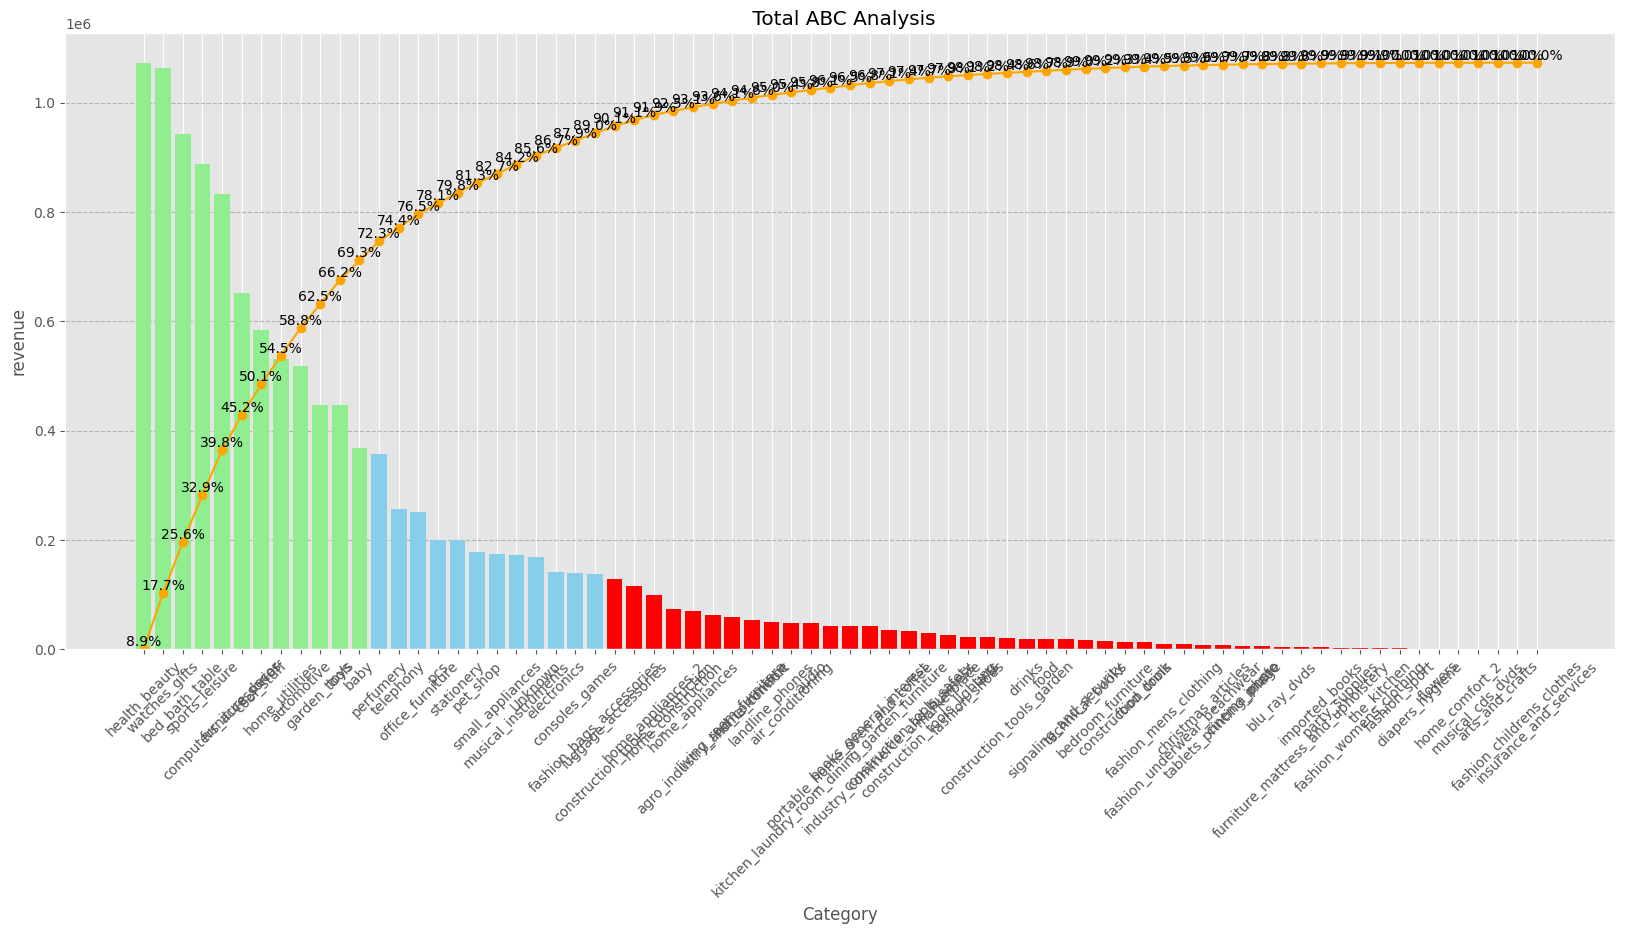

A 그룹 품목
 ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'cool_stuff', 'home_utilities', 'automotive', 'garden_tools', 'toys', 'baby']
B 그룹 품목
 ['perfumery', 'telephony', 'office_furniture', 'pcs', 'stationery', 'pet_shop', 'small_appliances', 'musical_instruments', 'Unknown', 'electronics', 'consoles_games', 'fashion_bags_accessories']


In [133]:
# 전체 카테고리 중요도 A,B 그룹 품목 선정
A,B = total(order_merge)

### 전체 기간, 최근 3개월 A,B 매출 품목 비율 증감률 구하기

In [134]:
# 처음 매출과 마지막 매출 비율 증감률 확인
# 최근 3개월 A,B 매출 품목 비율 증감률 확인

data=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kpi/data/cat_ratio.csv')

# 전체 카테고리 중요도 A,B 리스트 품목 가져오기
s_data_A = data[A]
s_data_B = data[B]

growth_rates_A={}
recent1_rates_A={}
recent2_rates_A={}

# 증감률 계산
for column in s_data_A.columns:
    first_row_value = s_data_A[column].iloc[0]
    last_row_value = s_data_A[column].iloc[-1]
    two_row_value = s_data_A[column].iloc[-2]
    three_row_value = s_data_A[column].iloc[-3]

    # 전체 증감률
    growth_rate = (last_row_value - first_row_value) / first_row_value * 100
    # 최근 1개월간 품목 매출 비율 증감률
    recent1_rate = (last_row_value - two_row_value) / two_row_value * 100
    # 한 달전 1개월간 품목 매출 비율 증감률
    recent2_rate = (two_row_value - three_row_value) / three_row_value * 100

    growth_rates_A[column] = growth_rate
    recent1_rates_A[column] = recent1_rate
    recent2_rates_A[column] = recent2_rate

# B
growth_rates_B={}
recent1_rates_B={}
recent2_rates_B={}

for column in s_data_B.columns:
    first_row_value = s_data_B[column].iloc[0]
    last_row_value = s_data_B[column].iloc[-1]
    two_row_value = s_data_B[column].iloc[-2]
    three_row_value = s_data_B[column].iloc[-3]

    growth_rate = (last_row_value - first_row_value) / first_row_value * 100
    recent1_rate = (last_row_value - two_row_value) / two_row_value * 100
    recent2_rate = (two_row_value - three_row_value) / three_row_value * 100

    growth_rates_B[column] = growth_rate
    recent1_rates_B[column] = recent1_rate
    recent2_rates_B[column] = recent2_rate

# 데이터 프레임화
growth_rates_A= pd.DataFrame(list(growth_rates_A.items()), columns=['Category', 'Total Growth_rate(%)'])
growth_rates_B = pd.DataFrame(list(growth_rates_B.items()), columns=['Category', 'Total Growth_rate(%)'])
recent1_rates_A = pd.DataFrame(list(recent1_rates_A.items()), columns=['Category', 'Recent1 Growth_rate(%)'])
recent2_rates_A = pd.DataFrame(list(recent2_rates_A.items()), columns=['Category', 'Recent2 Growth_rate(%)'])
recent1_rates_B = pd.DataFrame(list(recent1_rates_B.items()), columns=['Category', 'Recent1 Growth_rate(%)'])
recent2_rates_B = pd.DataFrame(list(recent2_rates_B.items()), columns=['Category', 'Recent2 Growth_rate(%)'])

### 분기별 예외 품목 구하기

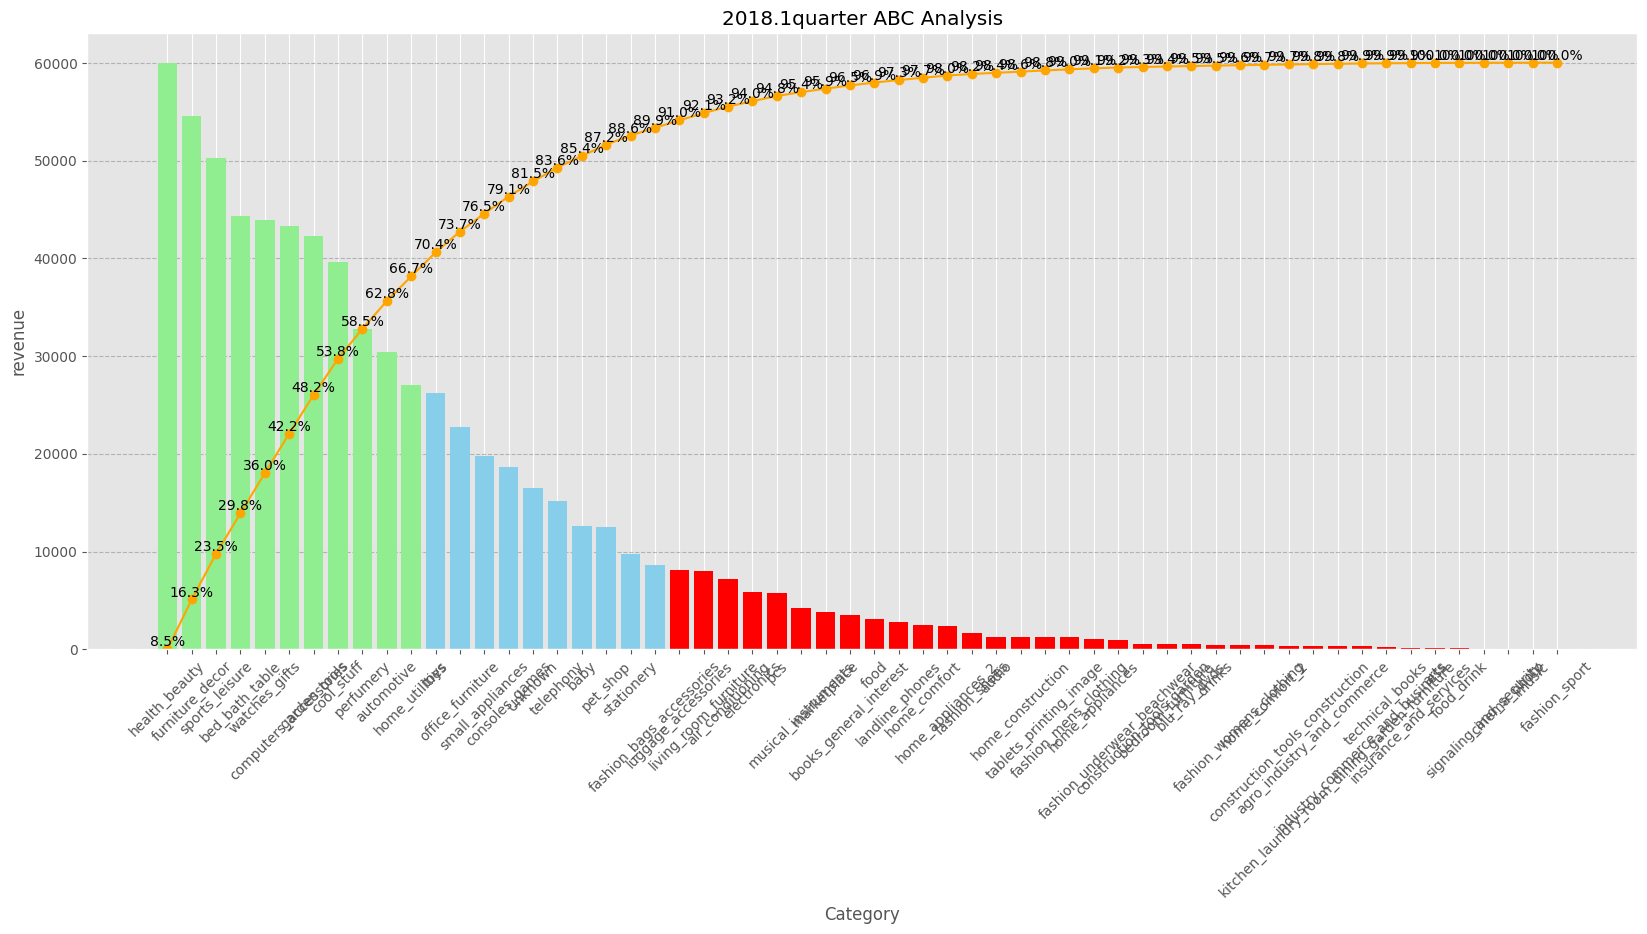

A 그룹 품목
 ['health_beauty', 'furniture_decor', 'sports_leisure', 'bed_bath_table', 'watches_gifts', 'computers_accessories', 'garden_tools', 'cool_stuff', 'perfumery', 'automotive', 'home_utilities']
B 그룹 품목
 ['toys', 'office_furniture', 'small_appliances', 'consoles_games', 'Unknown', 'telephony', 'baby', 'pet_shop', 'stationery', 'fashion_bags_accessories']


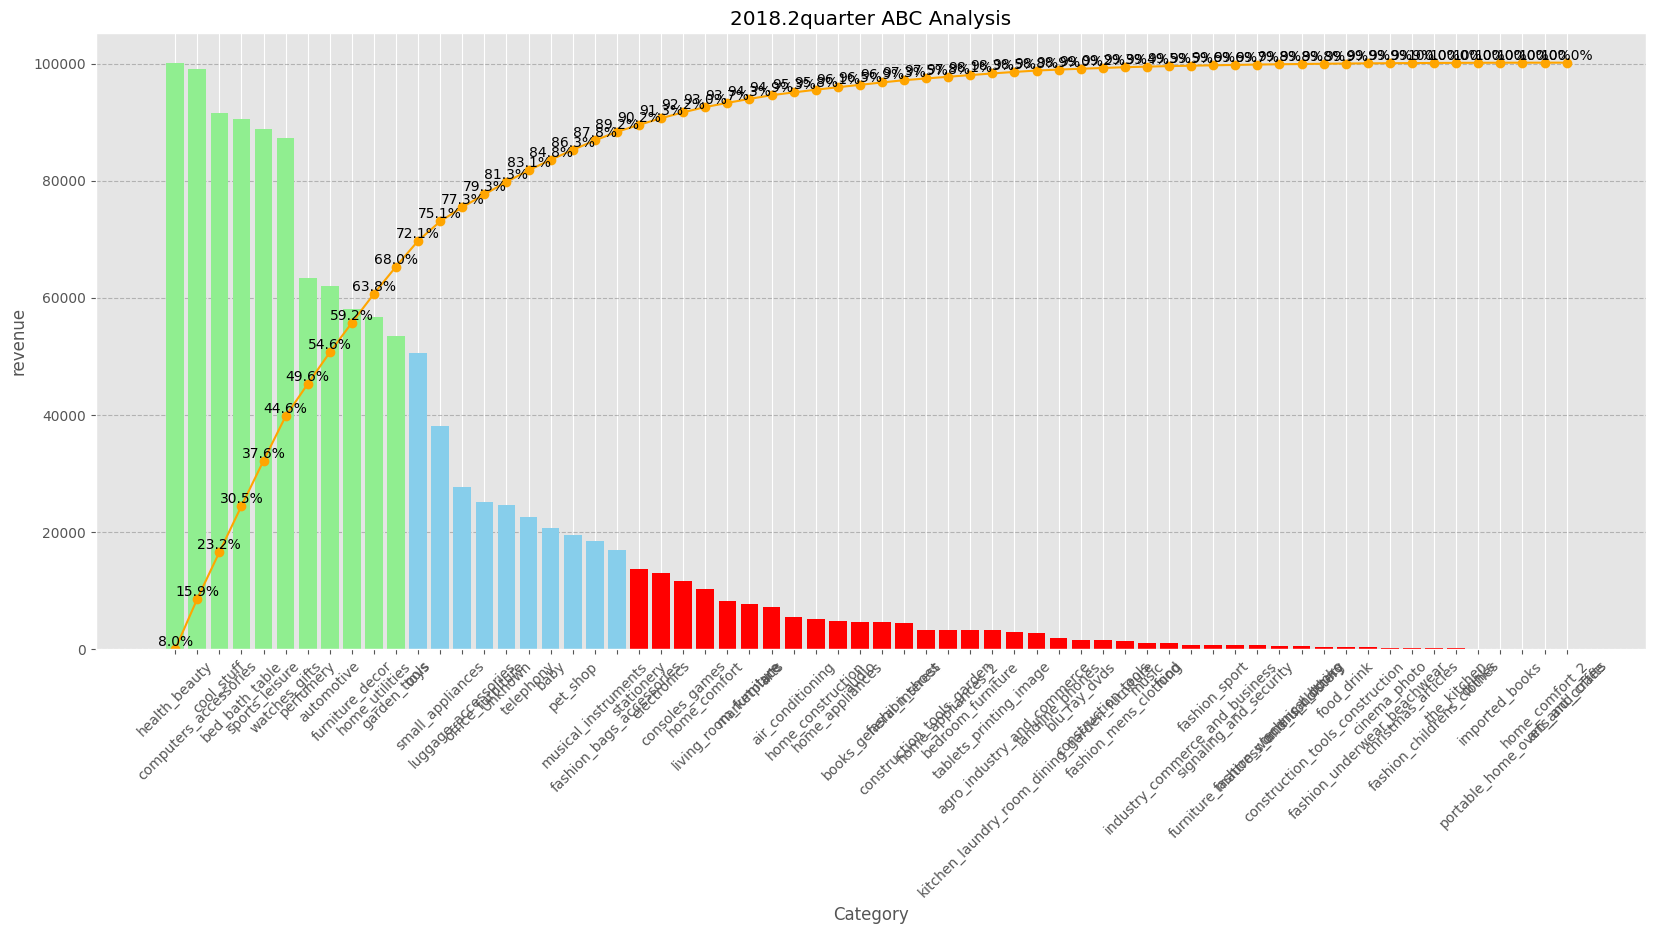

A 그룹 품목
 ['health_beauty', 'computers_accessories', 'cool_stuff', 'bed_bath_table', 'sports_leisure', 'watches_gifts', 'perfumery', 'automotive', 'furniture_decor', 'home_utilities', 'garden_tools']
B 그룹 품목
 ['toys', 'small_appliances', 'luggage_accessories', 'office_furniture', 'Unknown', 'telephony', 'baby', 'pet_shop', 'musical_instruments', 'fashion_bags_accessories']


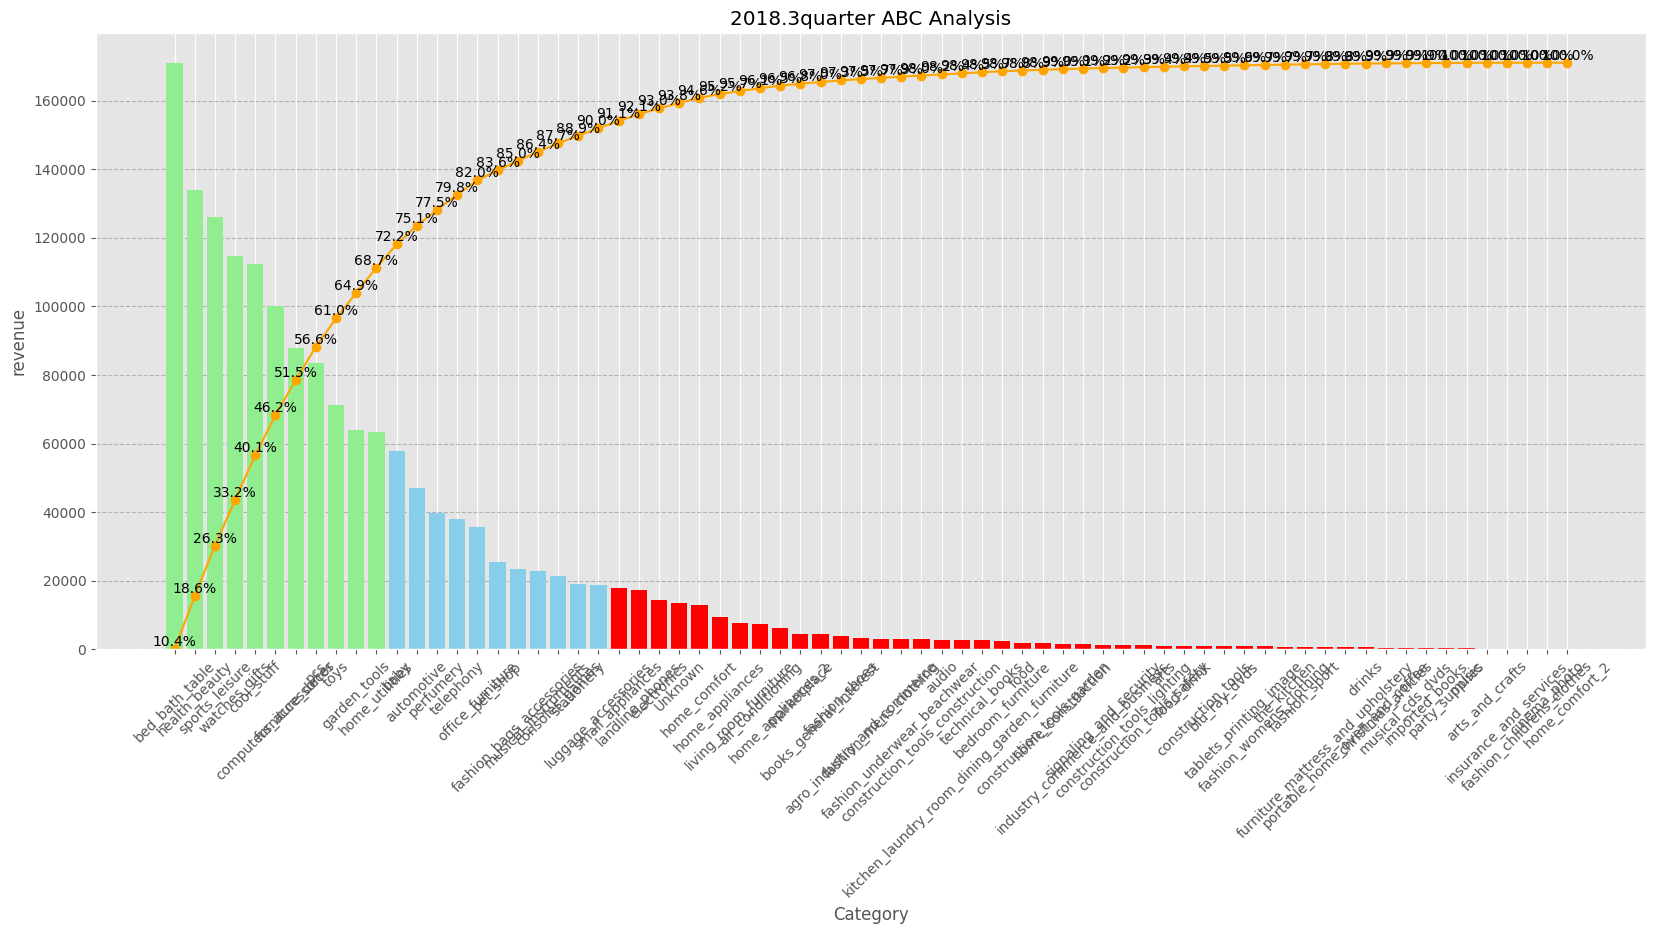

A 그룹 품목
 ['bed_bath_table', 'health_beauty', 'sports_leisure', 'watches_gifts', 'cool_stuff', 'computers_accessories', 'furniture_decor', 'pcs', 'toys', 'garden_tools', 'home_utilities']
B 그룹 품목
 ['baby', 'automotive', 'perfumery', 'telephony', 'office_furniture', 'pet_shop', 'fashion_bags_accessories', 'musical_instruments', 'consoles_games', 'stationery', 'luggage_accessories']


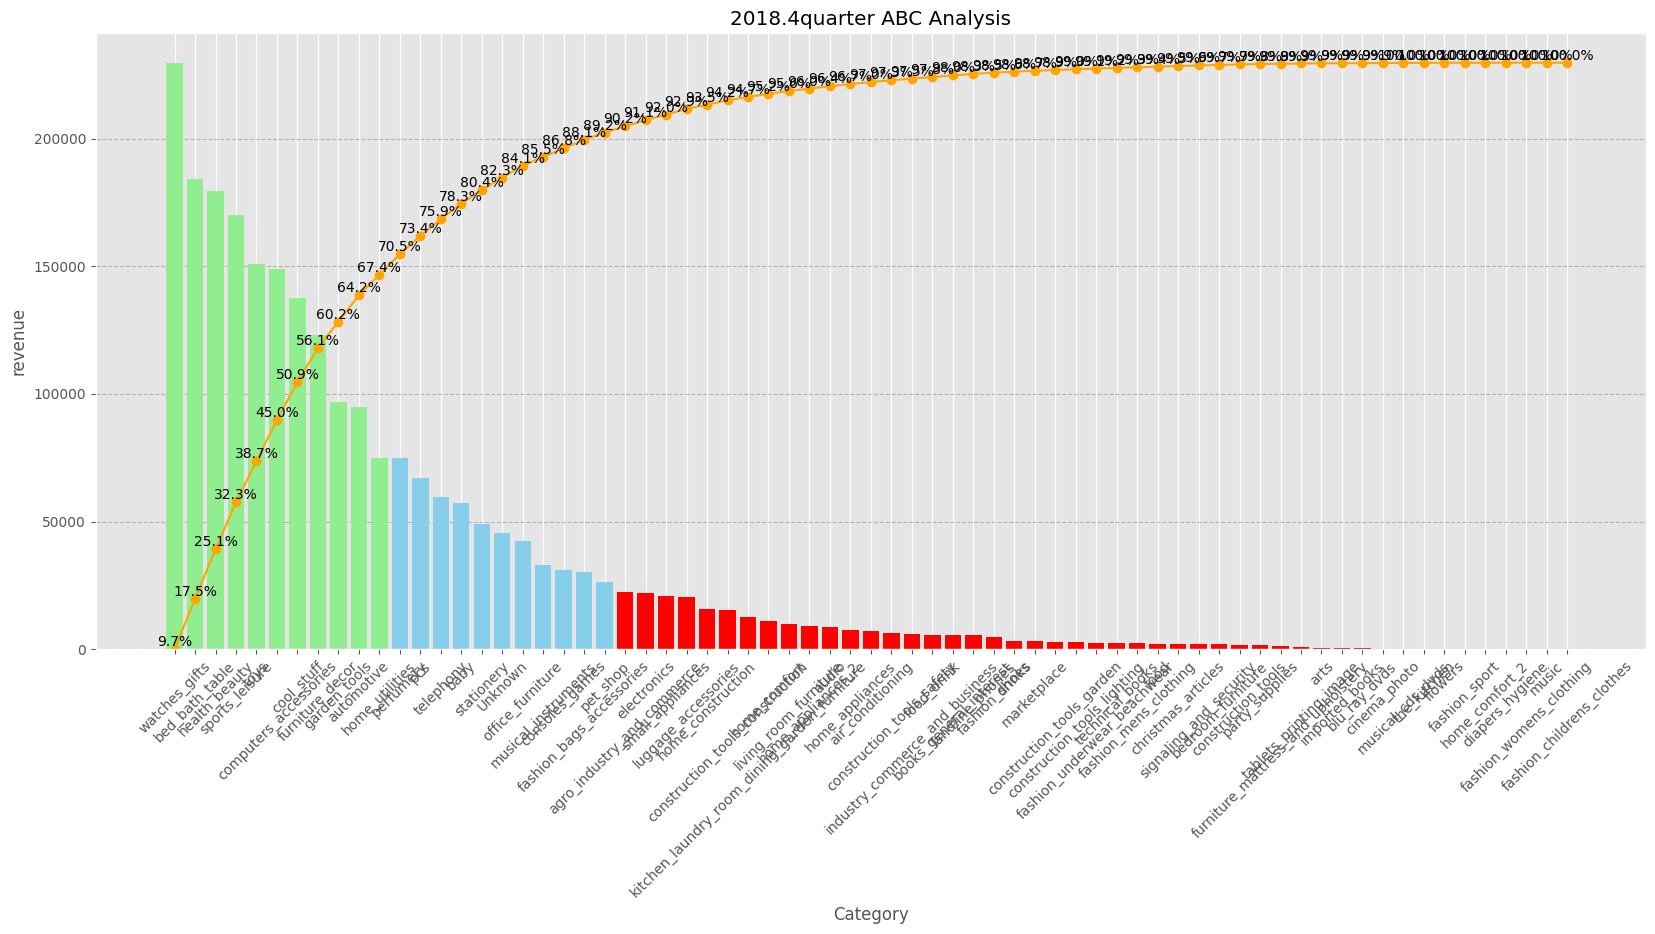

A 그룹 품목
 ['watches_gifts', 'bed_bath_table', 'health_beauty', 'sports_leisure', 'toys', 'computers_accessories', 'cool_stuff', 'furniture_decor', 'garden_tools', 'automotive', 'home_utilities']
B 그룹 품목
 ['perfumery', 'pcs', 'telephony', 'baby', 'stationery', 'Unknown', 'office_furniture', 'musical_instruments', 'consoles_games', 'fashion_bags_accessories', 'pet_shop']


In [135]:
# 분기별 예외 품목 선정
A_1,B_1 = quarter(order_merge,2018,1)
A_2,B_2 = quarter(order_merge,2018,2)
A_3,B_3 = quarter(order_merge,2018,3)
A_4,B_4 = quarter(order_merge,2018,4)

# 분기별 A,B 그룹에서 달라지는 품목 확인
un_data_A_1_2 = [order_merge for order_merge in A_1 + A_2 if order_merge not in A_1 or order_merge not in A_2]
un_data_A_2_3 = [order_merge for order_merge in A_2 + A_3 if order_merge not in A_2 or order_merge not in A_3]
un_data_A_3_4 = [order_merge for order_merge in A_3 + A_4 if order_merge not in A_3 or order_merge not in A_4]

un_data_B_1_2 = [order_merge for order_merge in B_1 + B_2 if order_merge not in B_1 or order_merge not in B_2]
un_data_B_2_3 = [order_merge for order_merge in B_2 + B_3 if order_merge not in B_2 or order_merge not in B_3]
un_data_B_3_4 = [order_merge for order_merge in B_3 + B_4 if order_merge not in B_3 or order_merge not in B_4]

# 중복을 제거한 분기별 예외 품목 리스트
un_data_A = list(set(un_data_A_1_2 + un_data_A_2_3 + un_data_A_3_4))
un_data_B = list(set(un_data_B_1_2 + un_data_B_2_3 + un_data_B_3_4))

In [136]:
# 분기별 달라진 품목 확인
un_data_A,un_data_B

(['pcs', 'automotive', 'toys', 'perfumery'],
 ['small_appliances',
  'pcs',
  'stationery',
  'Unknown',
  'automotive',
  'toys',
  'consoles_games',
  'musical_instruments',
  'luggage_accessories',
  'perfumery'])

### 분기별 예외 품목 판매 비율 시각화 함수

In [137]:
# 분기별 달라진 품목 매출 비율 시각화
def visual(data,category):

    # 분기별 매출 비율
    column_sum=[]
    vs = data[['index',category]]
    # 2018년 1분기 매출비율 더하기
    column_sum.append(sum(vs[category].iloc[0:3]))
    # 2018년 2분기 매출비율 더하기
    column_sum.append(sum(vs[category].iloc[3:6]))
    # 2018년 3분기 매출비율 더하기
    column_sum.append(sum(vs[category].iloc[6:9]))
    # 2018년 4분기 매출비율 더하기
    column_sum.append(sum(vs[category].iloc[9:12]))
    # 2019년 1분기 매출비율 더하기
    column_sum.append(sum(vs[category].iloc[12:15]))
    # 2019년 2분기 매출비율 더하기
    column_sum.append(sum(vs[category].iloc[15:18]))

    # X축 인덱스
    idx=['2018.1','2018.2','2018.3','2018.4','2019.1','2019.2']

    plt.figure(figsize=(4,4))
    plt.bar(idx, column_sum)
    plt.title(category)
    plt.show()
    return column_sum , idx

### 분기별 예외 품목 판매 비율 시각화 및 패턴 찾기

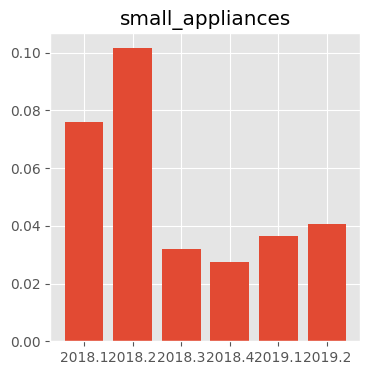

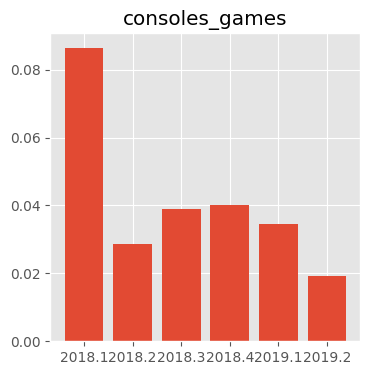

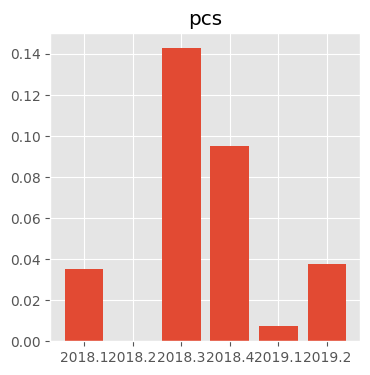

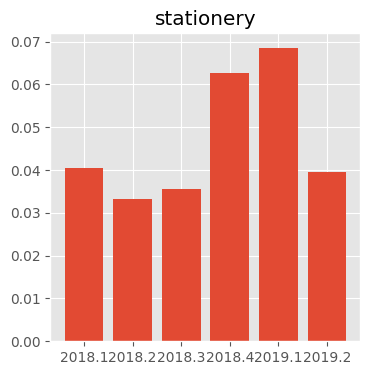

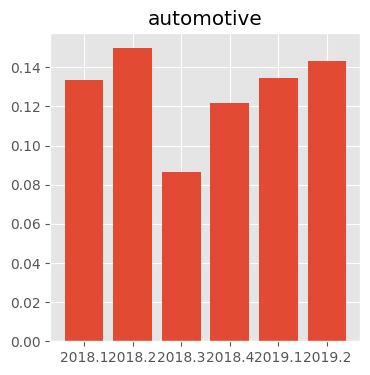

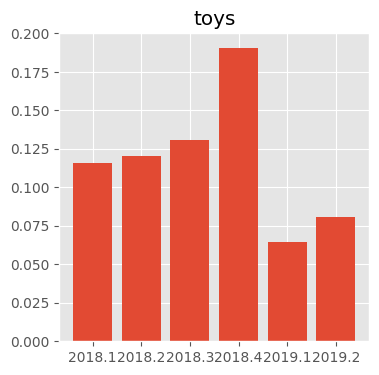

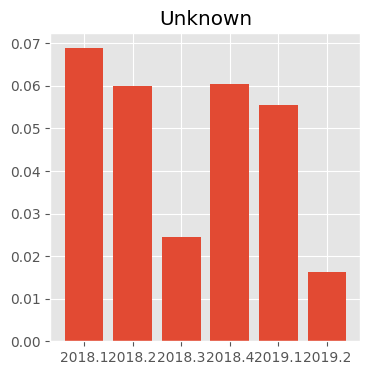

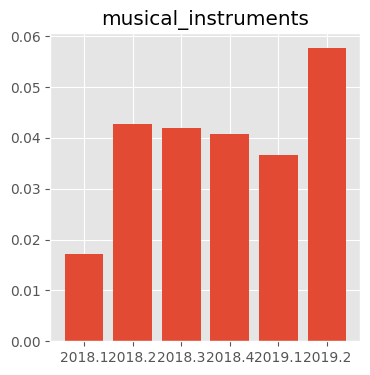

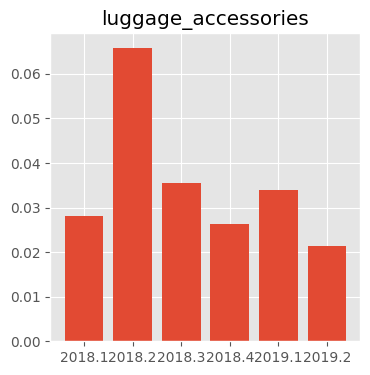

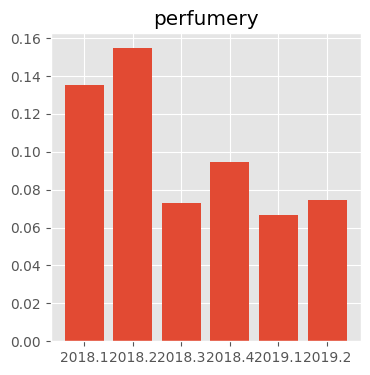

In [138]:
#매출 비율 csv 파일
data

# 예외 품목 후보 리스트
ex_s = list(set(un_data_A + un_data_B))
num_plots = len(ex_s)

# 시각화
for i in range(num_plots):
    visual(data,ex_s[i])

# 분기별 달라진 품목 확인
# 19년 3,4분기는 데이터가 없지만 그래프 추세로 예측

# toy 하반기로 갈수록 판매비율 증가 패턴 예측
# pcs 상반기 판매율 매우 저조 , 하반기 판매율 급증 패턴 예측

In [139]:
# 위 데이터 합치기
finish_A=pd.merge(growth_rates_A,recent1_rates_A, on = 'Category' , how='inner')
finish_A=pd.merge(finish_A,recent2_rates_A, on = 'Category' , how='inner')

finish_B=pd.merge(growth_rates_B,recent1_rates_B, on = 'Category' , how='inner')
finish_B=pd.merge(finish_B,recent2_rates_B, on = 'Category' , how='inner')

### A,B 품목 리스트

In [140]:
finish_A

,Category,Total Growth_rate(%),Recent1 Growth_rate(%),Recent2 Growth_rate(%)
0,health_beauty,5.229937,-6.415397,28.689370
1,watches_gifts,55.172414,12.500000,-18.233851
2,bed_bath_table,97.041420,-20.239521,14.855571
3,sports_leisure,-13.990268,34.155598,-13.179572
4,computers_accessories,32.386364,-4.703476,-5.780347
5,furniture_decor,-54.735013,6.326531,-10.420475
6,cool_stuff,-65.040650,-2.272727,-28.338762
7,home_utilities,173.622047,7.253086,0.465116
8,automotive,18.287037,-1.919386,24.641148
9,garden_tools,-46.119403,73.557692,-45.974026


In [141]:
finish_B

,Category,Total Growth_rate(%),Recent1 Growth_rate(%),Recent2 Growth_rate(%)
0,perfumery,-46.506550,-21.974522,25.099602
1,telephony,173.529412,-30.597015,38.144330
2,office_furniture,-44.230769,-59.722222,-32.710280
3,pcs,-76.649746,-68.493151,64.044944
4,stationery,22.142857,12.500000,18.750000
5,pet_shop,187.500000,-8.407080,88.333333
6,small_appliances,-16.107383,-27.325581,57.798165
7,musical_instruments,283.333333,-40.104167,3.225806
8,Unknown,-59.027778,110.714286,-46.153846
9,electronics,110.909091,1.754386,-31.325301


In [142]:
# A,B 품목 리스트 정규화 함수
scaler = MinMaxScaler()

# A
num_cols = finish_A.select_dtypes(include=['number']).columns

# 숫자형 열만 정규화
finish_A_n = finish_A.copy()
finish_A_n[num_cols] = scaler.fit_transform(finish_A_n[num_cols])

# B
num_cols = finish_B.select_dtypes(include=['number']).columns

finish_B_n = finish_B.copy()
finish_B_n[num_cols] = scaler.fit_transform(finish_B_n[num_cols])

### RCI값 추가

In [143]:
# RCI 컬럼 추가
# 전체 품목 매출 비율 증감률 가중치 = 0.4
# 최근 1개월전 품목 매출 비율 증감률 가중치 = 0.4
# 최근 2개월전 품목 매출 비율 증감률 가중치 = 0.2
# RCI = 전체 품목 매출 비율 증감률 *(0.4) + 최근 1개월간 품목 매출 비율 증감률*(0.4) + 한 달전 1개월간 품목 매출 비율 증감률 *(0.2)

finish_A_n['RCI']=finish_A_n['Total Growth_rate(%)']*0.4 + finish_A_n['Recent1 Growth_rate(%)']*0.4 + finish_A_n['Recent2 Growth_rate(%)']*0.2
finish_A_n=finish_A_n.sort_values(by='RCI', ascending=False)
finish_A_n

,Category,Total Growth_rate(%),Recent1 Growth_rate(%),Recent2 Growth_rate(%),RCI
7,home_utilities,1.000000,0.413511,0.621980,0.689800
2,bed_bath_table,0.679126,0.170329,0.814718,0.502726
8,automotive,0.349144,0.332377,0.945780,0.461765
1,watches_gifts,0.503694,0.459922,0.371536,0.459754
0,health_beauty,0.294435,0.292608,1.000000,0.434817
3,sports_leisure,0.213902,0.651474,0.439231,0.433996
9,garden_tools,0.079280,1.000000,0.000000,0.431712
4,computers_accessories,0.408221,0.307751,0.538332,0.394055
5,furniture_decor,0.043181,0.405315,0.476184,0.274635
6,cool_stuff,0.000000,0.329252,0.236197,0.178940


In [144]:
finish_B_n['RCI']=finish_B_n['Total Growth_rate(%)']*0.4 + finish_B_n['Recent1 Growth_rate(%)']*0.4 + finish_B_n['Recent2 Growth_rate(%)']*0.2
finish_B_n=finish_B_n.sort_values(by='RCI', ascending=False)
finish_B_n

,Category,Total Growth_rate(%),Recent1 Growth_rate(%),Recent2 Growth_rate(%),RCI
5,pet_shop,0.734615,0.335288,1.000000,0.627961
7,musical_instruments,1.000000,0.158414,0.367170,0.536800
1,telephony,0.695928,0.211465,0.626812,0.488320
8,Unknown,0.051923,1.000000,0.000000,0.420769
4,stationery,0.276703,0.451952,0.482602,0.387983
9,electronics,0.522517,0.391990,0.110260,0.387855
10,consoles_games,0.000000,0.444202,0.736011,0.324883
6,small_appliances,0.170780,0.229720,0.772951,0.314790
0,perfumery,0.086597,0.259580,0.529816,0.244434
3,pcs,0.003124,0.000000,0.819400,0.165130


### 최종 집중 품목 선정

In [145]:
# RCI 0.5 이상 + 예외(분기별 추천)

# A 그룹 품목 집중 품목
print_A = finish_A_n[finish_A_n['RCI']>=0.5][['Category','RCI']]
print_A

,Category,RCI
7,home_utilities,0.689800
2,bed_bath_table,0.502726


In [146]:
# B 그룹 품목 집중 품목
print_B = finish_B_n[finish_B_n['RCI']>=0.5][['Category','RCI']]
print_B

,Category,RCI
5,pet_shop,0.627961
7,musical_instruments,0.536800


In [147]:
# 예외 추천 품목 - toys , pcs